## PHASE 1 - DATA ANALYSIS

### Mount Google Drive

In [1]:
from pathlib import Path
# Locate the local dataset directory
base_path = Path(".")
if not (base_path / "landslide_dataset.csv").exists():
    base_path = Path("EARLY WARNING AND LAND SLIDE RISK MONITORING SYSTEM IN NER")
print(f"Local dataset directory: {base_path.resolve()}")

Local dataset directory: C:\Users\DELL\Downloads\LAND SLIDE RISK MONITORING SYSTEM (1)\EARLY WARNING AND LAND SLIDE RISK MONITORING SYSTEM IN NER


In [2]:
import pandas as pd

# Load datasets directly from the local folder
df_landslide = pd.read_csv(base_path / "Global_Landslide_Catalog_Export.csv")
df_rainfall = pd.read_csv(base_path / "district wise rainfall normal.csv")
df_flood = pd.read_csv(base_path / "urban_pluvial_flood_risk_dataset.csv")
df_landslide2 = pd.read_csv(base_path / "landslide_dataset.csv")

print("Landslide Catalog:", df_landslide.shape)
print("Rainfall:", df_rainfall.shape)
print("Flood Dataset:", df_flood.shape)
print("Landslide Dataset:", df_landslide2.shape)

Landslide Catalog: (11033, 31)
Rainfall: (641, 19)
Flood Dataset: (2963, 17)
Landslide Dataset: (2000, 10)


### Load all datasets

In [3]:
import pandas as pd

# Load datasets directly from the local folder
df_landslide = pd.read_csv(base_path / "Global_Landslide_Catalog_Export.csv")
df_rainfall = pd.read_csv(base_path / "district wise rainfall normal.csv")
df_flood = pd.read_csv(base_path / "urban_pluvial_flood_risk_dataset.csv")
df_landslide2 = pd.read_csv(base_path / "landslide_dataset.csv")

print("Landslide Catalog:", df_landslide.shape)
print("Rainfall:", df_rainfall.shape)
print("Flood Dataset:", df_flood.shape)
print("Landslide Dataset:", df_landslide2.shape)

Landslide Catalog: (11033, 31)
Rainfall: (641, 19)
Flood Dataset: (2963, 17)
Landslide Dataset: (2000, 10)


### Automatically Inspect Columns and Generate Dataset Profiling Report

In [4]:
# Install ydata-profiling for comprehensive data reports
!pip install ydata-profiling

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [5]:
import numpy as np
from IPython.display import display

def inspect_dataset(df, name):
    print(f"\n===== {name} =====")
    print(f"Rows: {len(df)}")
    print(f"Columns: {len(df.columns)}")
    print("\nData types:")
    print(df.dtypes)

    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print("\nMissing values:")
    if missing.empty:
        print("None")
    else:
        print(missing)

    print("\nDuplicate rows:", df.duplicated().sum())
    print("\nNumeric summary:")
    numeric = df.select_dtypes(include=[np.number])
    if not numeric.empty:
        print(numeric.describe().T)
    else:
        print("No numeric columns")

    print("\nSample rows:")
    display(df.head())

inspect_dataset(df_landslide, "df_landslide")
inspect_dataset(df_rainfall, "df_rainfall")
inspect_dataset(df_flood, "df_flood")
inspect_dataset(df_landslide2, "df_landslide2")


===== df_landslide =====
Rows: 11033
Columns: 31

Data types:
source_name                   object
source_link                   object
event_id                       int64
event_date                    object
event_time                   float64
event_title                   object
event_description             object
location_description          object
location_accuracy             object
landslide_category            object
landslide_trigger             object
landslide_size                object
landslide_setting             object
fatality_count               float64
injury_count                 float64
storm_name                    object
photo_link                    object
notes                         object
event_import_source           object
event_import_id              float64
country_name                  object
country_code                  object
admin_division_name           object
admin_division_population    float64
gazeteer_closest_point        object
gazeteer_dis

,source_name,source_link,event_id,event_date,event_time,event_title,event_description,location_description,location_accuracy,landslide_category,...,country_code,admin_division_name,admin_division_population,gazeteer_closest_point,gazeteer_distance,submitted_date,created_date,last_edited_date,longitude,latitude
0,AGU,https://blogs.agu.org/landslideblog/2008/10/14...,684,08/01/2008 12:00:00 AM,NaN,"Sigou Village, Loufan County, Shanxi Province","occurred early in morning, 11 villagers buried...","Sigou Village, Loufan County, Shanxi Province",unknown,landslide,...,CN,Shaanxi,0.0,Jingyang,41.02145,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,107.4500,32.5625
1,Oregonian,http://www.oregonlive.com/news/index.ssf/2009/...,956,01/02/2009 02:00:00 AM,NaN,"Lake Oswego, Oregon",Hours of heavy rain are to blame for an overni...,"Lake Oswego, Oregon",5km,mudslide,...,US,Oregon,36619.0,Lake Oswego,0.60342,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,-122.6630,45.4200
2,CBS News,https://www.cbsnews.com/news/dozens-missing-af...,973,01/19/2007 12:00:00 AM,NaN,"San Ramon district, 195 miles northeast of the...",(CBS/AP) At least 10 people died and as many a...,"San Ramon district, 195 miles northeast of the...",10km,landslide,...,PE,Junín,14708.0,San Ramón,0.85548,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,-75.3587,-11.1295
3,Reuters,https://in.reuters.com/article/idINIndia-41450...,1067,07/31/2009 12:00:00 AM,NaN,Dailekh district,"One person was killed in Dailekh district, pol...",Dailekh district,unknown,landslide,...,NP,Mid Western,20908.0,Dailekh,0.75395,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,81.7080,28.8378
4,The Freeman,http://www.philstar.com/cebu-news/621414/lands...,2603,10/16/2010 12:00:00 PM,NaN,sitio Bakilid in barangay Lahug,Another landslide in sitio Bakilid in barangay...,sitio Bakilid in barangay Lahug,5km,landslide,...,PH,Central Visayas,798634.0,Cebu City,2.02204,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,123.8978,10.3336



===== df_rainfall =====
Rows: 641
Columns: 19

Data types:
STATE_UT_NAME     object
DISTRICT          object
JAN              float64
FEB              float64
MAR              float64
APR              float64
MAY              float64
JUN              float64
JUL              float64
AUG              float64
SEP              float64
OCT              float64
NOV              float64
DEC              float64
ANNUAL           float64
Jan-Feb          float64
Mar-May          float64
Jun-Sep          float64
Oct-Dec          float64
dtype: object

Missing values:
None

Duplicate rows: 0

Numeric summary:
         count         mean         std   min    25%     50%     75%     max
JAN      641.0    18.355070   21.082806   0.0    6.9    13.3    19.2   144.5
FEB      641.0    20.984399   27.729596   0.0    7.0    12.3    24.1   229.6
MAR      641.0    30.034789   45.451082   0.0    7.0    12.7    33.2   367.9
APR      641.0    45.543214   71.556279   0.0    5.0    15.1    48.3   554.4
MAY    

,STATE_UT_NAME,DISTRICT,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
0,ANDAMAN And NICOBAR ISLANDS,NICOBAR,107.3,57.9,65.2,117.0,358.5,295.5,285.0,271.9,354.8,326.0,315.2,250.9,2805.2,165.2,540.7,1207.2,892.1
1,ANDAMAN And NICOBAR ISLANDS,SOUTH ANDAMAN,43.7,26.0,18.6,90.5,374.4,457.2,421.3,423.1,455.6,301.2,275.8,128.3,3015.7,69.7,483.5,1757.2,705.3
2,ANDAMAN And NICOBAR ISLANDS,N & M ANDAMAN,32.7,15.9,8.6,53.4,343.6,503.3,465.4,460.9,454.8,276.1,198.6,100.0,2913.3,48.6,405.6,1884.4,574.7
3,ARUNACHAL PRADESH,LOHIT,42.2,80.8,176.4,358.5,306.4,447.0,660.1,427.8,313.6,167.1,34.1,29.8,3043.8,123.0,841.3,1848.5,231.0
4,ARUNACHAL PRADESH,EAST SIANG,33.3,79.5,105.9,216.5,323.0,738.3,990.9,711.2,568.0,206.9,29.5,31.7,4034.7,112.8,645.4,3008.4,268.1



===== df_flood =====
Rows: 2963
Columns: 17

Data types:
segment_id                              object
city_name                               object
admin_ward                              object
latitude                               float64
longitude                              float64
catchment_id                            object
elevation_m                            float64
dem_source                              object
land_use                                object
soil_group                              object
drainage_density_km_per_km2            float64
storm_drain_proximity_m                float64
storm_drain_type                        object
rainfall_source                         object
historical_rainfall_intensity_mm_hr    float64
return_period_years                      int64
risk_labels                             object
dtype: object

Missing values:
elevation_m                    161
soil_group                     362
drainage_density_km_per_km2    284
storm_d

,segment_id,city_name,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_labels
0,SEG-00001,"Colombo, Sri Lanka",Borough East,6.920633,79.912600,CAT-136,NaN,Copernicus_EEA-10_v5,Institutional,NaN,4.27,160.5,CurbInlet,ERA5,39.4,50,monitor
1,SEG-00002,"Chennai, India",Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,D,7.54,NaN,OpenChannel,ERA5,56.8,25,ponding_hotspot|low_lying|event_2025-05-02
2,SEG-00003,"Ahmedabad, India",Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,B,11.00,152.5,OpenChannel,IMD,16.3,5,monitor
3,SEG-00004,"Hong Kong, China",Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,B,7.32,37.0,Manhole,ERA5,77.0,10,monitor
4,SEG-00005,"Durban, South Africa",Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,C,4.50,292.4,OpenChannel,ERA5,20.8,5,monitor



===== df_landslide2 =====
Rows: 2000
Columns: 10

Data types:
Rainfall_mm            float64
Slope_Angle            float64
Soil_Saturation        float64
Vegetation_Cover       float64
Earthquake_Activity    float64
Proximity_to_Water     float64
Landslide                int64
Soil_Type_Gravel         int64
Soil_Type_Sand           int64
Soil_Type_Silt           int64
dtype: object

Missing values:
None

Duplicate rows: 0

Numeric summary:
                      count        mean        std        min         25%  \
Rainfall_mm          2000.0  176.688462  65.724685  50.036151  128.379762   
Slope_Angle          2000.0   29.985404  15.175902   5.003944   18.018061   
Soil_Saturation      2000.0    0.540316   0.295665   0.000652    0.265634   
Vegetation_Cover     2000.0    0.522862   0.260426   0.100005    0.295475   
Earthquake_Activity  2000.0    3.604771   1.895955   0.001641    1.973415   
Proximity_to_Water   2000.0    1.001867   0.579964   0.000653    0.500808   
Landslide      

,Rainfall_mm,Slope_Angle,Soil_Saturation,Vegetation_Cover,Earthquake_Activity,Proximity_to_Water,Landslide,Soil_Type_Gravel,Soil_Type_Sand,Soil_Type_Silt
0,206.181018,58.275001,0.892798,0.339463,4.390047,0.099975,1,0,0,0
1,218.887334,36.679801,0.657147,0.360355,4.141029,0.832443,1,0,0,1
2,181.850867,31.363874,0.673362,0.221697,5.311891,0.023062,1,0,0,1
3,228.716199,38.995134,0.618666,0.489502,4.581928,0.785176,1,0,0,1
4,179.951067,42.998205,0.836966,0.118580,5.518862,0.450499,1,0,0,0


### Handle Missing Values

In [6]:
print("\n--- Missing Values Before Handling ---")

print("\nMissing values in df_landslide:")
print(df_landslide.isnull().sum()[df_landslide.isnull().sum() > 0])

print("\nMissing values in df_rainfall:")
print(df_rainfall.isnull().sum()[df_rainfall.isnull().sum() > 0])

print("\nMissing values in df_flood:")
print(df_flood.isnull().sum()[df_flood.isnull().sum() > 0])

print("\nMissing values in df_landslide2:")
print(df_landslide2.isnull().sum()[df_landslide2.isnull().sum() > 0])


# Strategy for handling missing values (This is a general approach and might need refinement based on data insights)
# 1. For numerical columns, impute with mean or median.
# 2. For categorical columns, impute with mode or a 'Unknown' category.
# 3. For columns with a very high percentage of missing values, consider dropping them.

# --- df_landslide ---
# Drop columns with high percentage of missing values or those not directly relevant for initial modeling
df_landslide = df_landslide.drop(columns=['event_time', 'storm_name', 'photo_link', 'notes'], errors='ignore')

# Impute numerical columns with median
for col in ['fatality_count', 'injury_count', 'event_import_id', 'admin_division_population', 'gazeteer_distance']:
    if col in df_landslide.columns:
        df_landslide[col].fillna(df_landslide[col].median(), inplace=True)

# Impute categorical/object columns with mode or 'Unknown'
for col in ['source_link', 'event_description', 'location_description', 'location_accuracy',
            'landslide_category', 'landslide_trigger', 'landslide_size', 'landslide_setting',
            'event_import_source', 'country_name', 'country_code', 'admin_division_name',
            'gazeteer_closest_point', 'submitted_date', 'created_date']:
    if col in df_landslide.columns:
        # For 'event_date', 'submitted_date', 'created_date', 'last_edited_date', convert to datetime later
        if df_landslide[col].dtype == 'object':
             df_landslide[col].fillna(df_landslide[col].mode()[0] if not df_landslide[col].mode().empty else 'Unknown', inplace=True)


# --- df_rainfall ---
# All numerical, impute with mean (rainfall data is usually continuous)
for col in df_rainfall.columns[2:]:
    df_rainfall[col].fillna(df_rainfall[col].mean(), inplace=True)

# --- df_flood ---
# For numerical columns, impute with median
for col in ['population_density', 'elevation_m', 'avg_annual_rainfall', 'drainage_capacity', 'land_use_mix',
            'drainage_density_km_per_km2', 'storm_drain_proximity_m']:
    if col in df_flood.columns:
        df_flood[col].fillna(df_flood[col].median(), inplace=True)

# For categorical columns, impute with mode or 'Unknown'
for col in ['city_name', 'admin_ward', 'flood_risk_level', 'risk_factors', 'soil_group', 'storm_drain_type', 'rainfall_source']:
     if col in df_flood.columns and df_flood[col].dtype == 'object':
         df_flood[col].fillna(df_flood[col].mode()[0] if not df_flood[col].mode().empty else 'Unknown', inplace=True)

# --- df_landslide2 ---
# All numerical, impute with mean
for col in df_landslide2.columns:
    df_landslide2[col].fillna(df_landslide2[col].mean(), inplace=True)


print("\n--- Missing Values After Handling ---")

print("\nMissing values in df_landslide:")
print(df_landslide.isnull().sum()[df_landslide.isnull().sum() > 0])

print("\nMissing values in df_rainfall:")
print(df_rainfall.isnull().sum()[df_rainfall.isnull().sum() > 0])

print("\nMissing values in df_flood:")
print(df_flood.isnull().sum()[df_flood.isnull().sum() > 0])

print("\nMissing values in df_landslide2:")
print(df_landslide2.isnull().sum()[df_landslide2.isnull().sum() > 0])


print("\nMissing values handling complete.")


--- Missing Values Before Handling ---

Missing values in df_landslide:
source_link                    846
event_time                   11033
event_description              862
location_description           102
location_accuracy                2
landslide_category               1
landslide_trigger               23
landslide_size                   9
landslide_setting               69
fatality_count                1385
injury_count                  5674
storm_name                   10456
photo_link                    9537
notes                        10716
event_import_source           1563
event_import_id               1562
country_name                  1562
country_code                  1564
admin_division_name           1637
admin_division_population     1562
gazeteer_closest_point        1563
gazeteer_distance             1562
submitted_date                  10
created_date                     1
dtype: int64

Missing values in df_rainfall:
Series([], dtype: int64)

Missing values i

C:\Users\DELL\AppData\Local\Temp\ipykernel_9800\1431006187.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_landslide[col].fillna(df_landslide[col].median(), inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_9800\1431006187.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

### Remove Duplicates

In [7]:
print("\n--- Duplicates Before Handling ---")

print(f"df_landslide has {df_landslide.duplicated().sum()} duplicate rows.")
print(f"df_rainfall has {df_rainfall.duplicated().sum()} duplicate rows.")
print(f"df_flood has {df_flood.duplicated().sum()} duplicate rows.")
print(f"df_landslide2 has {df_landslide2.duplicated().sum()} duplicate rows.")

# Remove duplicate rows from each DataFrame
df_landslide.drop_duplicates(inplace=True)
df_rainfall.drop_duplicates(inplace=True)
df_flood.drop_duplicates(inplace=True)
df_landslide2.drop_duplicates(inplace=True)

print("\n--- Duplicates After Handling ---")

print(f"df_landslide now has {df_landslide.duplicated().sum()} duplicate rows.")
print(f"df_rainfall now has {df_rainfall.duplicated().sum()} duplicate rows.")
print(f"df_flood now has {df_flood.duplicated().sum()} duplicate rows.")
print(f"df_landslide2 now has {df_landslide2.duplicated().sum()} duplicate rows.")

print("\nDuplicate removal complete.")


--- Duplicates Before Handling ---


df_landslide has 0 duplicate rows.
df_rainfall has 0 duplicate rows.
df_flood has 0 duplicate rows.
df_landslide2 has 0 duplicate rows.

--- Duplicates After Handling ---
df_landslide now has 0 duplicate rows.
df_rainfall now has 0 duplicate rows.
df_flood now has 0 duplicate rows.
df_landslide2 now has 0 duplicate rows.

Duplicate removal complete.


### Detect Outliers


--- Outlier Detection using IQR Method ---

*** df_landslide Outlier Analysis ***

Outliers in fatality_count (2442 detected):
count    2442.000000
mean       12.719492
std       118.543805
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max      5000.000000
Name: fatality_count, dtype: float64


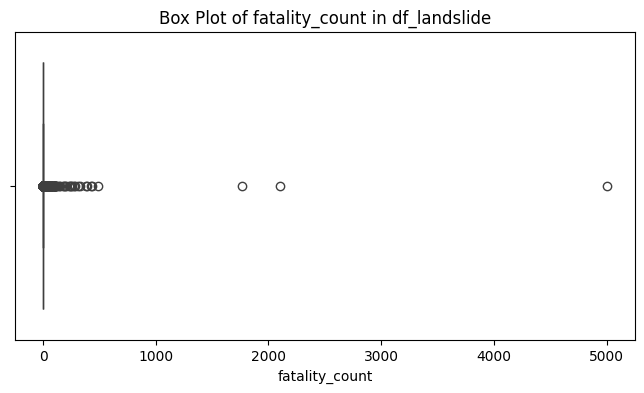


Outliers in injury_count (575 detected):
count    575.000000
mean       7.006957
std       24.980270
min        1.000000
25%        1.000000
50%        2.000000
75%        5.000000
max      374.000000
Name: injury_count, dtype: float64


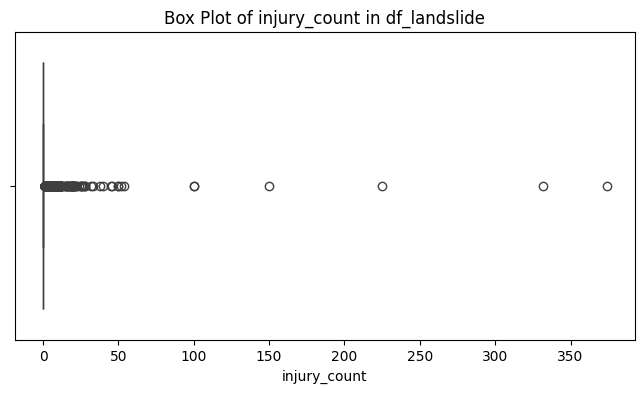


Outliers in longitude (0 detected):
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: longitude, dtype: float64


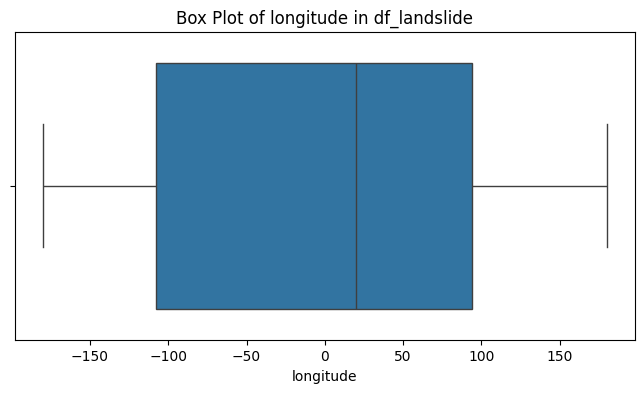


Outliers in latitude (287 detected):
count    287.000000
mean     -37.302814
std        5.009680
min      -46.774800
25%      -41.267800
50%      -37.784600
75%      -33.972450
max      -26.583300
Name: latitude, dtype: float64


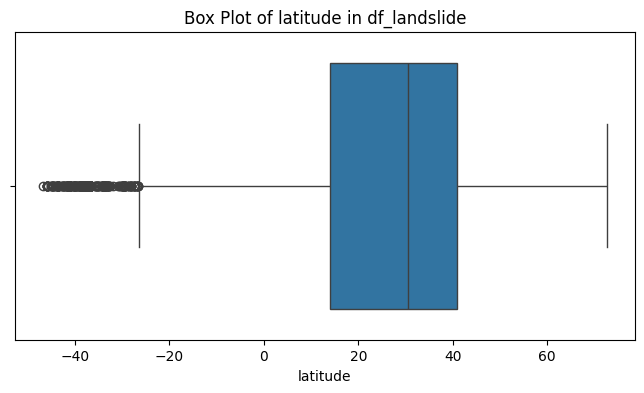


Outliers in admin_division_population (1774 detected):
count    1.774000e+03
mean     7.978641e+05
std      1.781014e+06
min      6.079700e+04
25%      9.418800e+04
50%      2.000000e+05
75%      5.837760e+05
max      1.269184e+07
Name: admin_division_population, dtype: float64


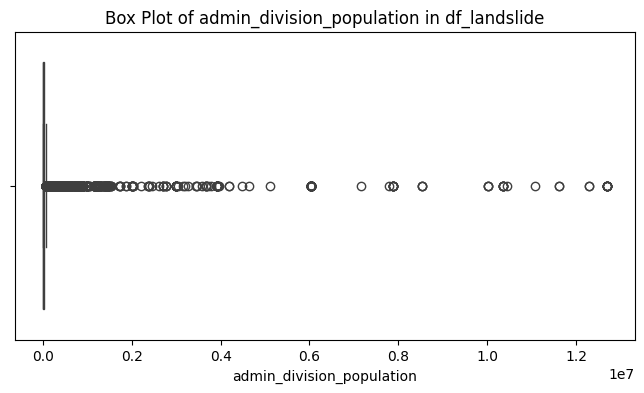


Outliers in gazeteer_distance (946 detected):
count    946.000000
mean      47.696663
std       22.783239
min       29.550660
25%       33.937810
50%       40.818575
75%       52.090120
max      215.448880
Name: gazeteer_distance, dtype: float64


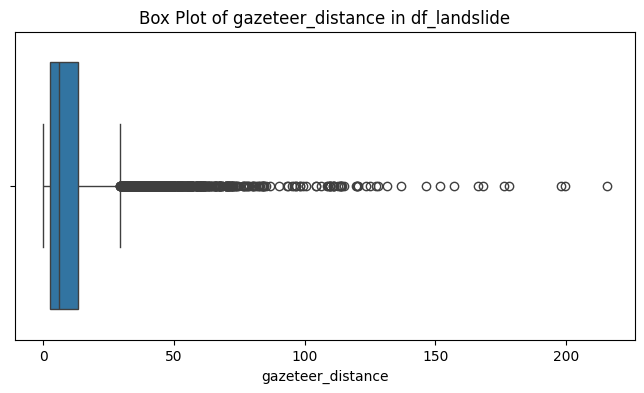


*** df_rainfall Outlier Analysis ***

Outliers in JAN (71 detected):
count     71.000000
mean      68.291549
std       26.941061
min       38.400000
25%       46.250000
50%       59.300000
75%       83.100000
max      144.500000
Name: JAN, dtype: float64


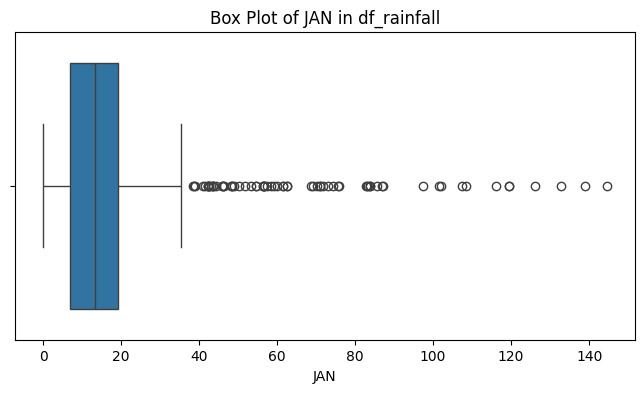


Outliers in FEB (59 detected):
count     59.000000
mean      91.601695
std       41.242481
min       49.900000
25%       66.350000
50%       72.900000
75%      108.550000
max      229.600000
Name: FEB, dtype: float64


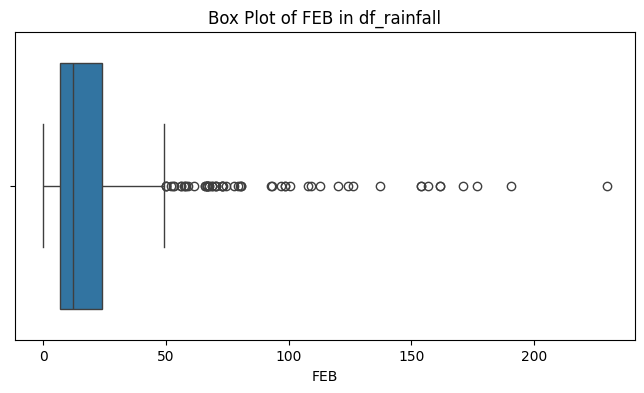


Outliers in MAR (70 detected):
count     70.000000
mean     135.051429
std       65.458408
min       72.700000
25%       85.325000
50%      114.500000
75%      158.800000
max      367.900000
Name: MAR, dtype: float64


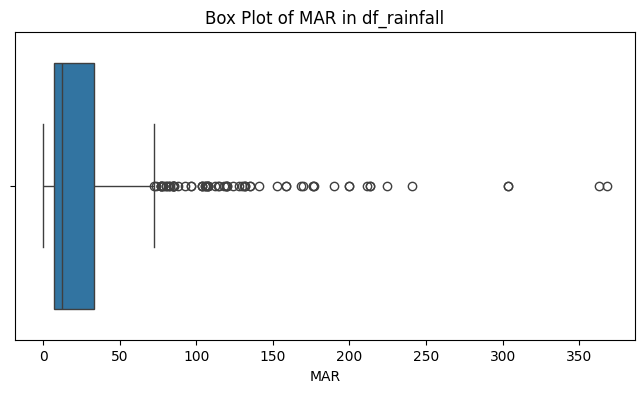


Outliers in APR (93 detected):
count     93.000000
mean     193.303226
std       80.346071
min      113.400000
25%      137.900000
50%      175.700000
75%      216.400000
max      554.400000
Name: APR, dtype: float64


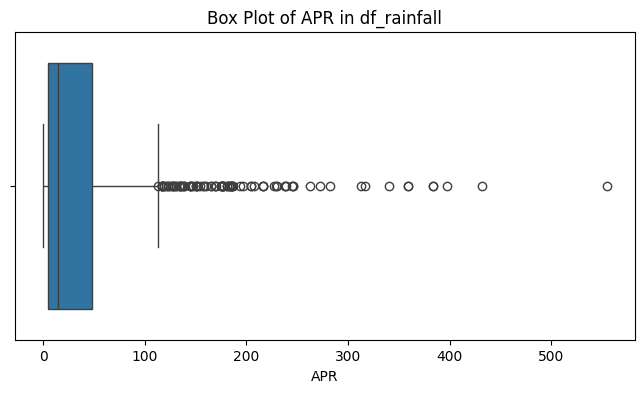


Outliers in MAY (88 detected):
count     88.000000
mean     331.396591
std       88.058950
min      216.600000
25%      273.150000
50%      320.000000
75%      355.400000
max      733.700000
Name: MAY, dtype: float64


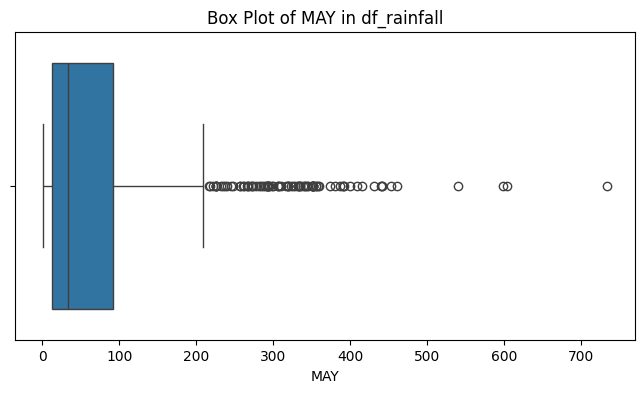


Outliers in JUN (66 detected):
count      66.000000
mean      666.678788
std       207.993029
min       464.300000
25%       526.725000
50%       626.300000
75%       705.075000
max      1476.200000
Name: JUN, dtype: float64


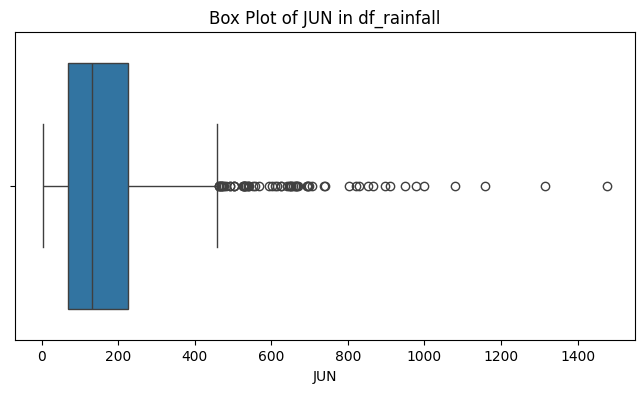


Outliers in JUL (48 detected):
count      48.000000
mean      928.972917
std       261.322360
min       646.000000
25%       755.150000
50%       858.050000
75%      1054.100000
max      1820.900000
Name: JUL, dtype: float64


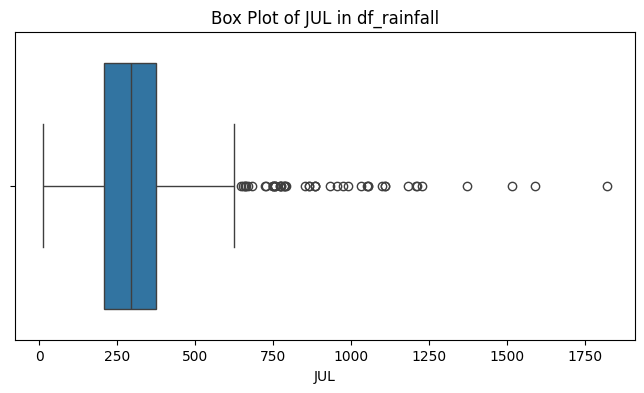


Outliers in AUG (24 detected):
count      24.000000
mean      761.245833
std       196.616477
min       607.900000
25%       653.400000
50%       677.450000
75%       838.400000
max      1522.100000
Name: AUG, dtype: float64


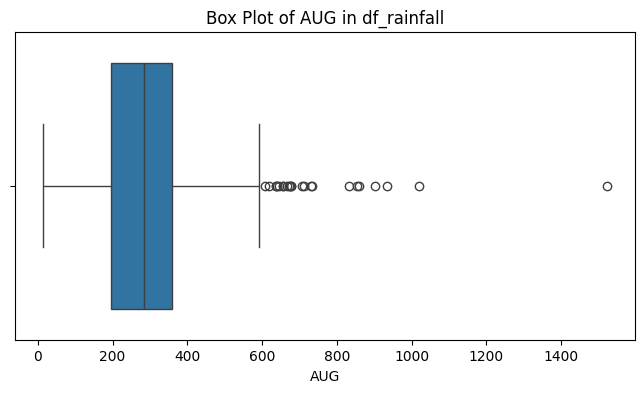


Outliers in SEP (27 detected):
count     27.000000
mean     489.959259
std      106.599207
min      398.300000
25%      418.500000
50%      462.100000
75%      491.600000
max      826.300000
Name: SEP, dtype: float64


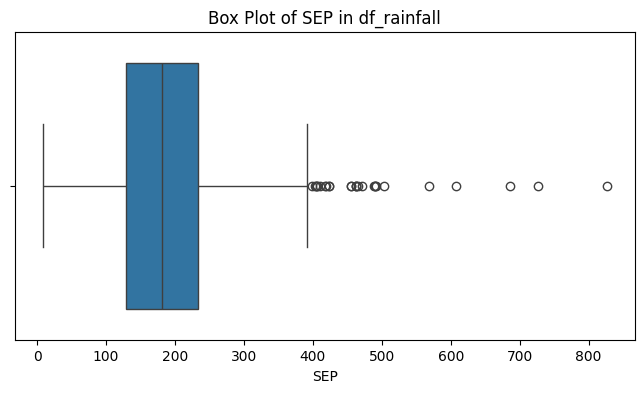


Outliers in OCT (16 detected):
count     16.00000
mean     326.69375
std       60.84180
min      275.00000
25%      287.27500
50%      308.90000
75%      347.25000
max      517.70000
Name: OCT, dtype: float64


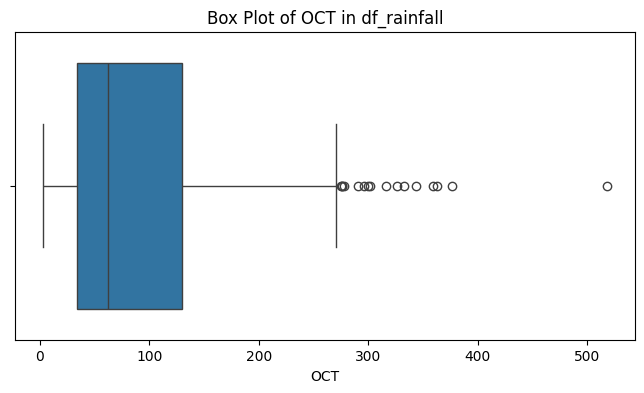


Outliers in NOV (67 detected):
count     67.000000
mean     178.134328
std       91.923334
min       71.600000
25%      116.350000
50%      148.500000
75%      209.350000
max      475.100000
Name: NOV, dtype: float64


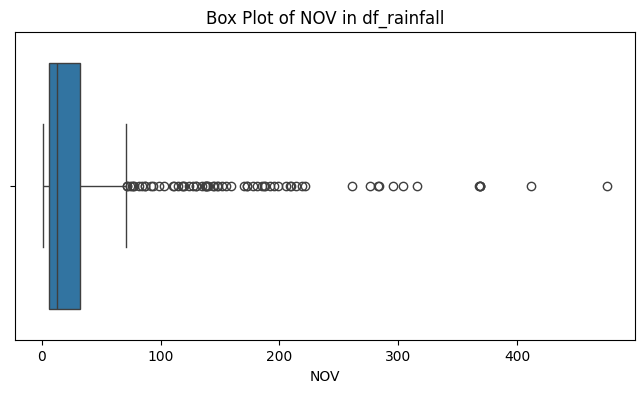


Outliers in DEC (86 detected):
count     86.000000
mean      79.693023
std       58.401190
min       29.500000
25%       42.875000
50%       57.600000
75%       93.750000
max      297.700000
Name: DEC, dtype: float64


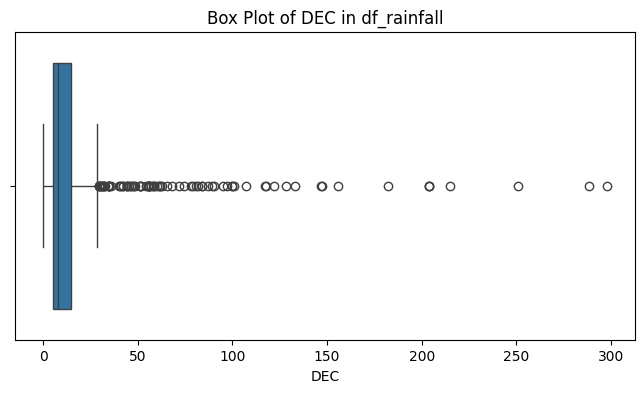


Outliers in ANNUAL (61 detected):
count      61.000000
mean     3345.908197
std       851.994001
min      2582.200000
25%      2859.300000
50%      3118.500000
75%      3468.300000
max      7229.300000
Name: ANNUAL, dtype: float64


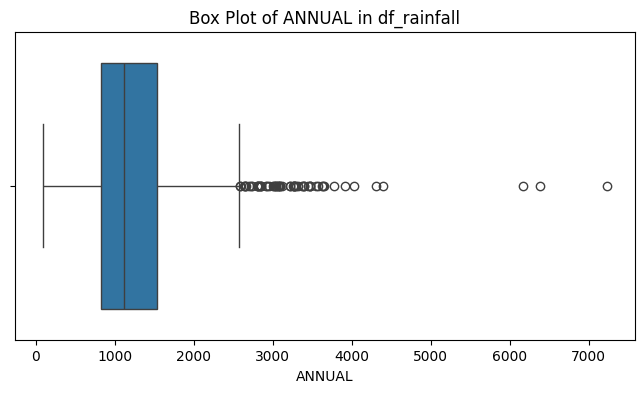


Outliers in Jan-Feb (70 detected):
count     70.000000
mean     151.210000
std       63.450833
min       81.000000
25%      102.100000
50%      127.650000
75%      183.900000
max      335.300000
Name: Jan-Feb, dtype: float64


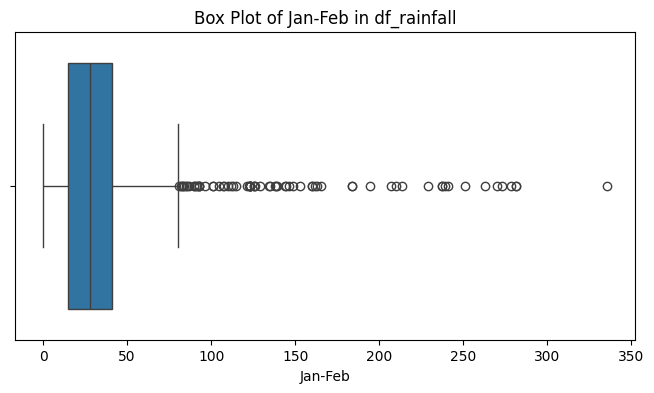


Outliers in Mar-May (89 detected):
count      89.000000
mean      619.947191
std       190.689924
min       405.600000
25%       483.500000
50%       562.900000
75%       660.600000
max      1256.500000
Name: Mar-May, dtype: float64


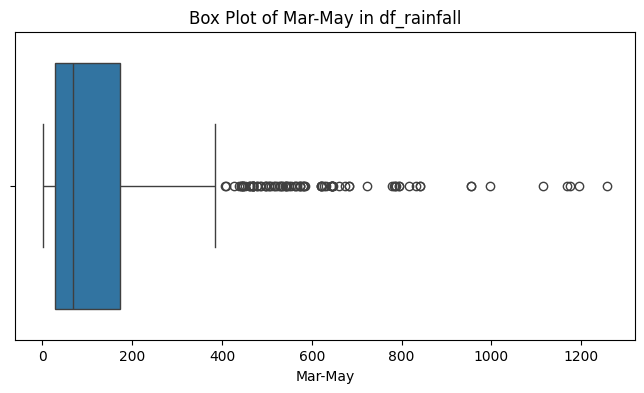


Outliers in Jun-Sep (41 detected):
count      41.000000
mean     2758.048780
std       709.927769
min      2060.400000
25%      2296.100000
50%      2558.800000
75%      3007.500000
max      5228.000000
Name: Jun-Sep, dtype: float64


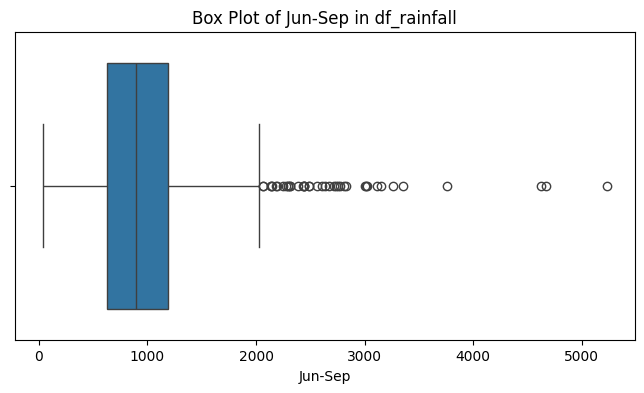


Outliers in Oct-Dec (47 detected):
count      47.000000
mean      565.031915
std       165.555246
min       362.900000
25%       432.200000
50%       522.700000
75%       638.950000
max      1048.500000
Name: Oct-Dec, dtype: float64


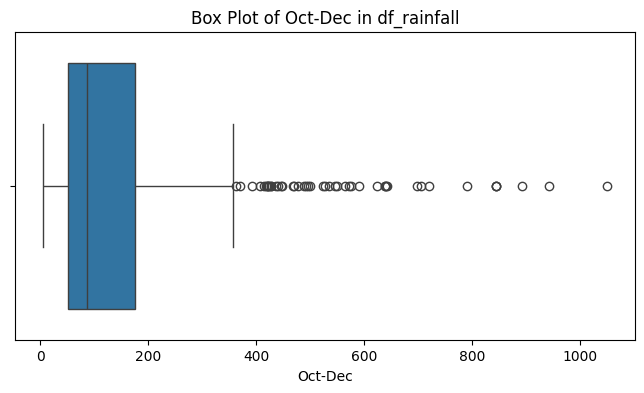


*** df_flood Outlier Analysis ***

Outliers in elevation_m (75 detected):
count     75.000000
mean     168.506267
std       35.317232
min      128.370000
25%      139.095000
50%      156.420000
75%      196.205000
max      266.700000
Name: elevation_m, dtype: float64


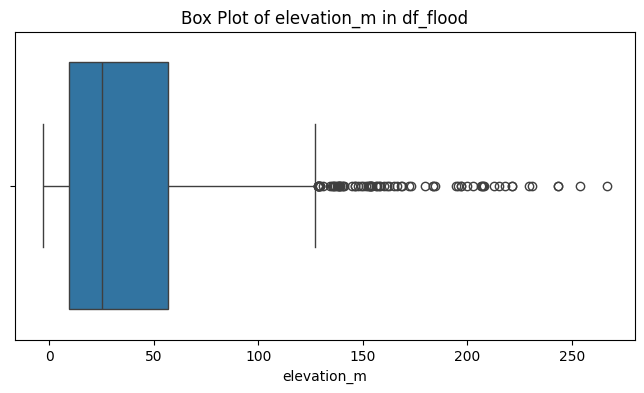


Outliers in drainage_density_km_per_km2 (3 detected):
count     3.000000
mean     12.043333
std       0.046188
min      11.990000
25%      12.030000
50%      12.070000
75%      12.070000
max      12.070000
Name: drainage_density_km_per_km2, dtype: float64


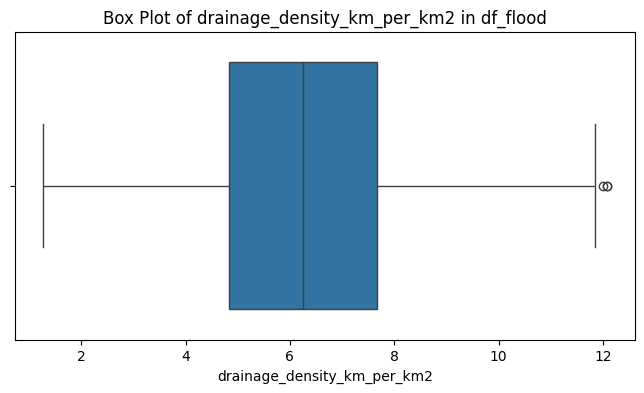


Outliers in storm_drain_proximity_m (196 detected):
count    196.000000
mean     403.872449
std       79.114787
min      312.100000
25%      348.750000
50%      382.600000
75%      444.325000
max      751.700000
Name: storm_drain_proximity_m, dtype: float64


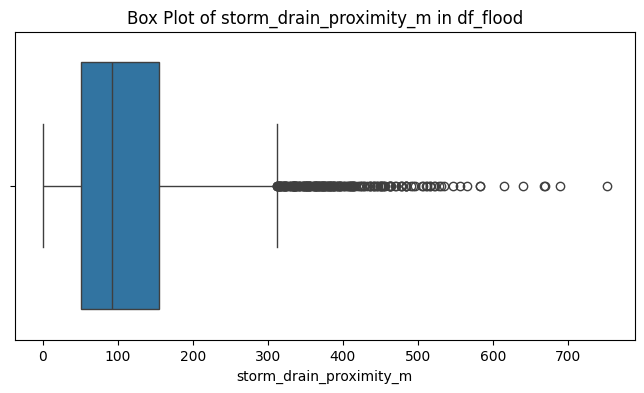


*** df_landslide2 Outlier Analysis ***

Outliers in Rainfall_mm (0 detected):
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Rainfall_mm, dtype: float64


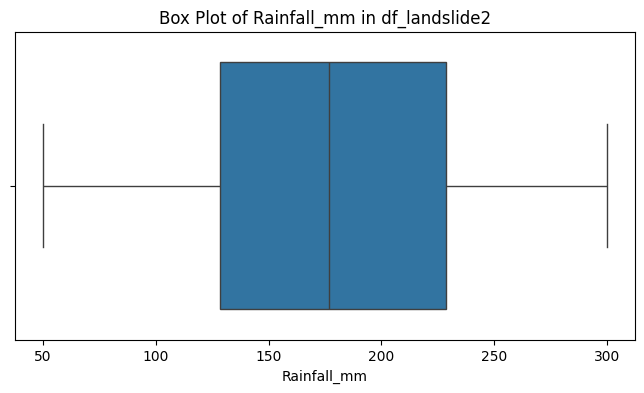


Outliers in Slope_Angle (0 detected):
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Slope_Angle, dtype: float64


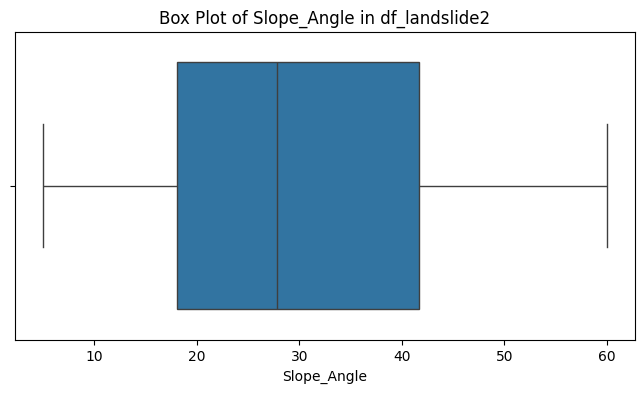


Outliers in Soil_Saturation (0 detected):
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Soil_Saturation, dtype: float64


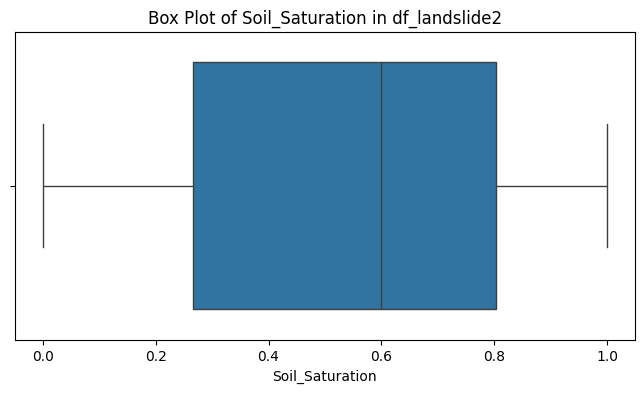


Outliers in Vegetation_Cover (0 detected):
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Vegetation_Cover, dtype: float64


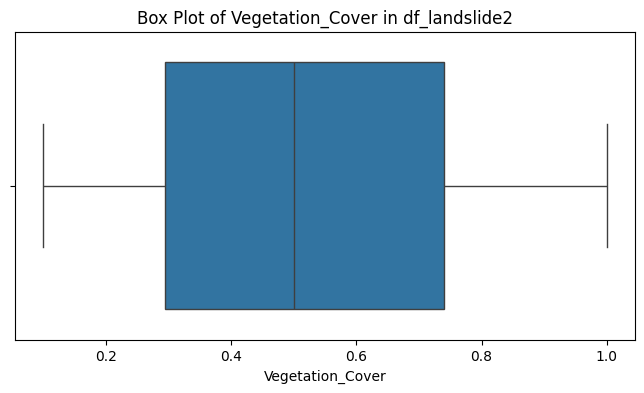


Outliers in Earthquake_Activity (0 detected):
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Earthquake_Activity, dtype: float64


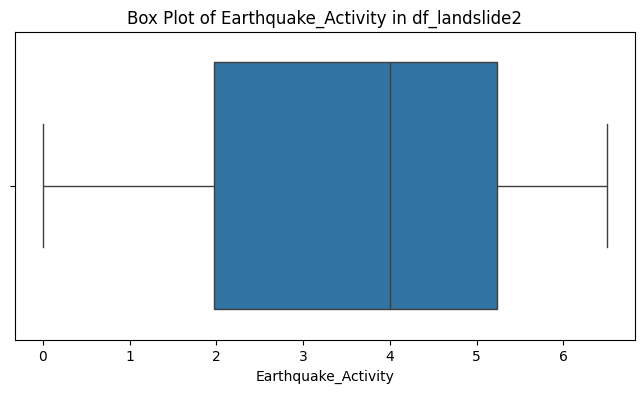


Outliers in Proximity_to_Water (0 detected):
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Proximity_to_Water, dtype: float64


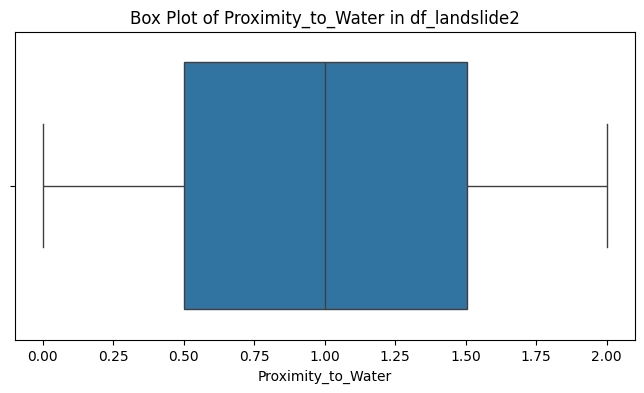


Outliers in Landslide (0 detected):
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Landslide, dtype: float64


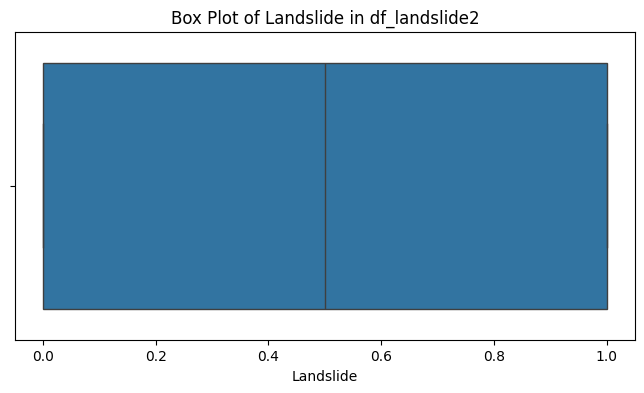


Outliers in Soil_Type_Gravel (0 detected):
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Soil_Type_Gravel, dtype: float64


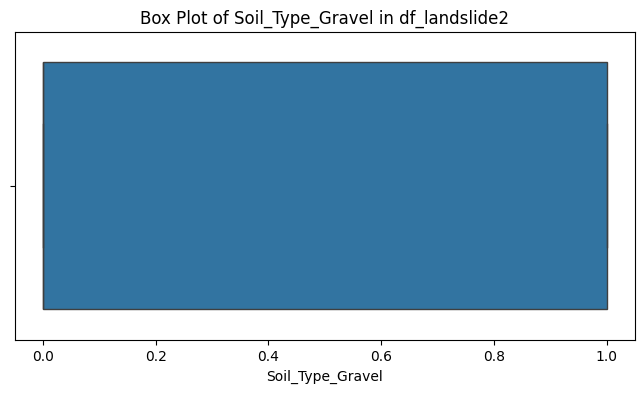


Outliers in Soil_Type_Sand (483 detected):
count    483.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: Soil_Type_Sand, dtype: float64


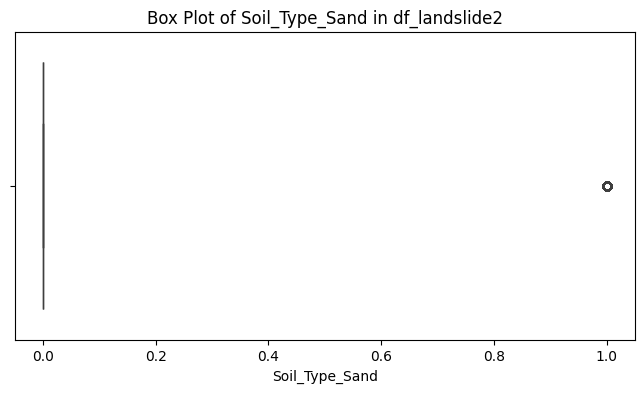


Outliers in Soil_Type_Silt (0 detected):
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Soil_Type_Silt, dtype: float64


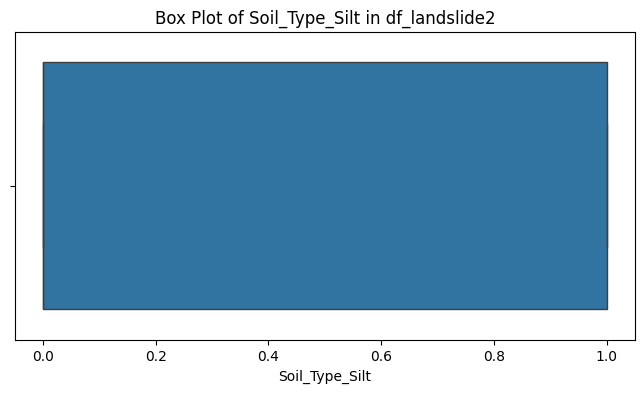


Outlier detection complete. Visualizations provide a detailed view.
Note: Depending on the nature of the data, outliers may not always need to be removed but should be understood.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
    print(f"\nOutliers in {column} ({len(outliers)} detected):\n{outliers.describe()}")
    return outliers

print("\n--- Outlier Detection using IQR Method ---")

# --- df_landslide ---
print("\n*** df_landslide Outlier Analysis ***")
# Focus on numerical columns that are relevant and not identifiers
landslide_numeric_cols = ['fatality_count', 'injury_count', 'longitude', 'latitude',
                          'admin_division_population', 'gazeteer_distance']
for col in landslide_numeric_cols:
    if col in df_landslide.columns and pd.api.types.is_numeric_dtype(df_landslide[col]):
        detect_outliers_iqr(df_landslide, col)

        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df_landslide[col])
        plt.title(f'Box Plot of {col} in df_landslide')
        plt.show()

# --- df_rainfall ---
print("\n*** df_rainfall Outlier Analysis ***")
rainfall_numeric_cols = df_rainfall.select_dtypes(include=np.number).columns.tolist()
# Exclude year/identifier columns if present
exclude_cols = ['id', 'Year'] # Add any other non-data columns that might be present
rainfall_numeric_cols = [col for col in rainfall_numeric_cols if col not in exclude_cols]
for col in rainfall_numeric_cols:
    detect_outliers_iqr(df_rainfall, col)
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_rainfall[col])
    plt.title(f'Box Plot of {col} in df_rainfall')
    plt.show()

# --- df_flood ---
print("\n*** df_flood Outlier Analysis ***")
flood_numeric_cols = ['population_density', 'elevation_m', 'avg_annual_rainfall',
                      'drainage_capacity', 'land_use_mix', 'drainage_density_km_per_km2',
                      'storm_drain_proximity_m']
for col in flood_numeric_cols:
    if col in df_flood.columns and pd.api.types.is_numeric_dtype(df_flood[col]):
        detect_outliers_iqr(df_flood, col)
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df_flood[col])
        plt.title(f'Box Plot of {col} in df_flood')
        plt.show()

# --- df_landslide2 ---
print("\n*** df_landslide2 Outlier Analysis ***")
landslide2_numeric_cols = df_landslide2.select_dtypes(include=np.number).columns.tolist()
for col in landslide2_numeric_cols:
    detect_outliers_iqr(df_landslide2, col)
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_landslide2[col])
    plt.title(f'Box Plot of {col} in df_landslide2')
    plt.show()


print("\nOutlier detection complete. Visualizations provide a detailed view.")
print("Note: Depending on the nature of the data, outliers may not always need to be removed but should be understood.")

### Create Visualizations


--- Generating Visualizations ---

*** df_landslide Visualizations ***


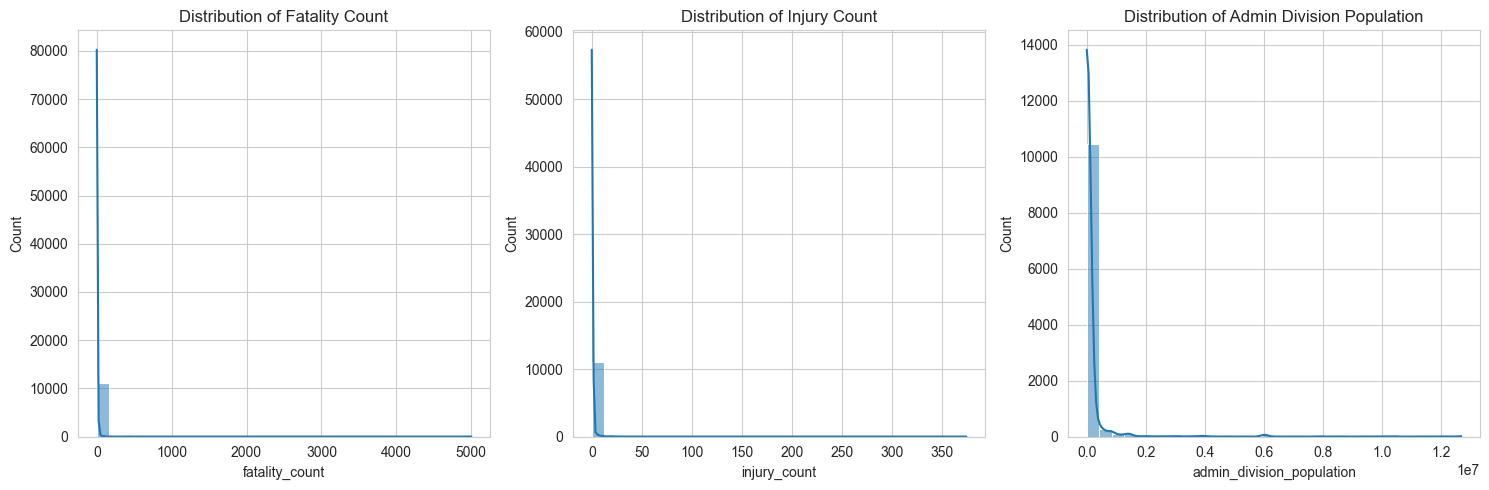

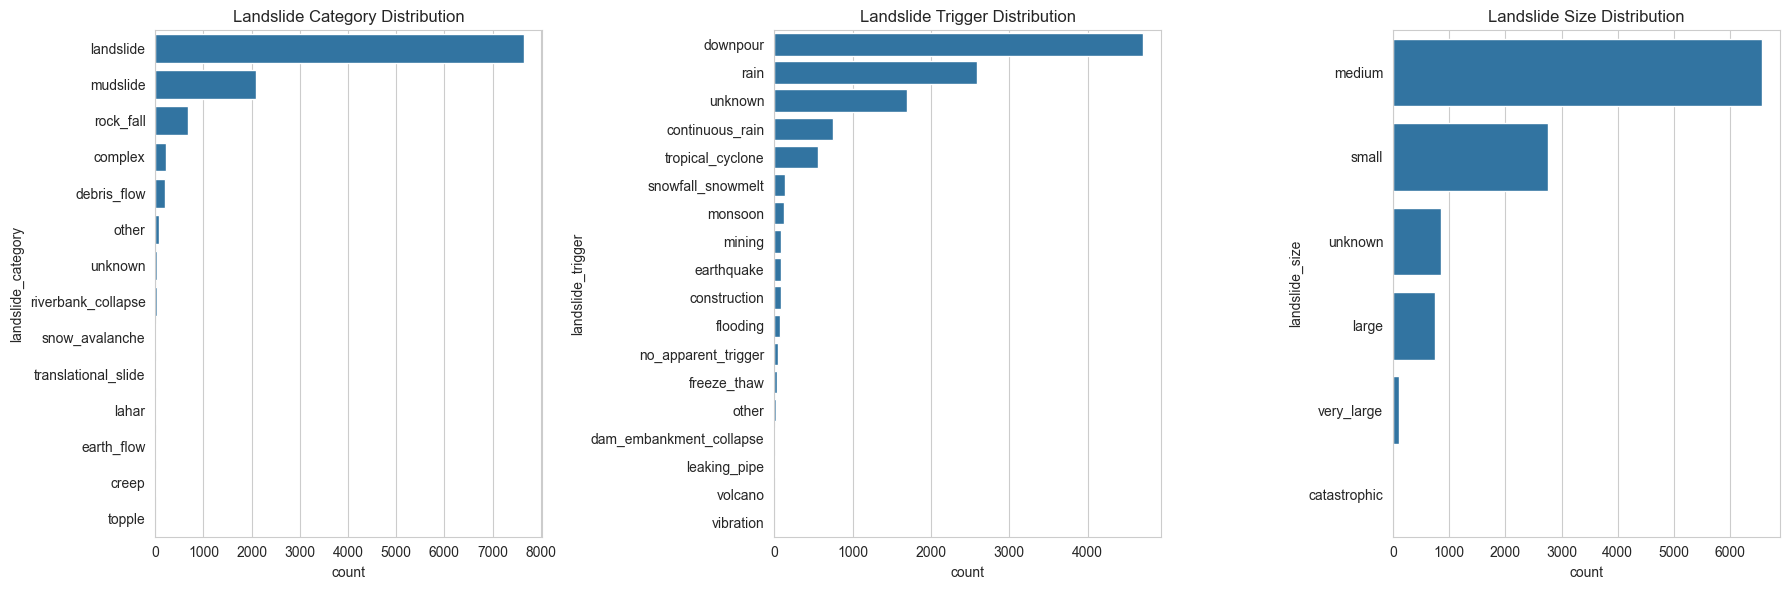


*** df_rainfall Visualizations ***


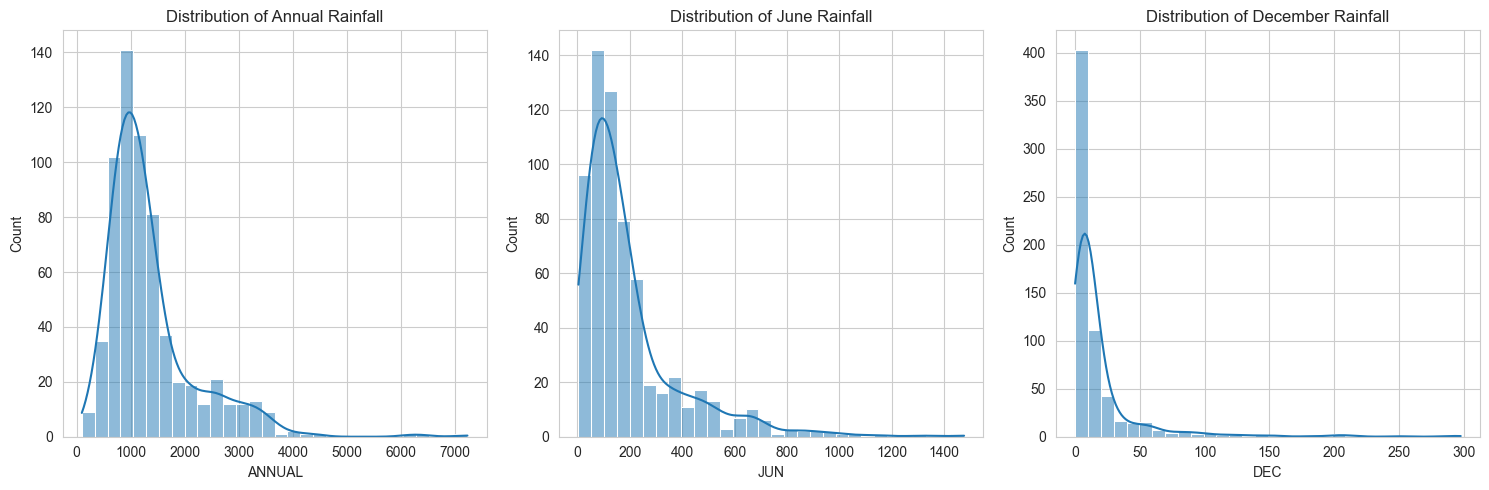


*** df_flood Visualizations ***


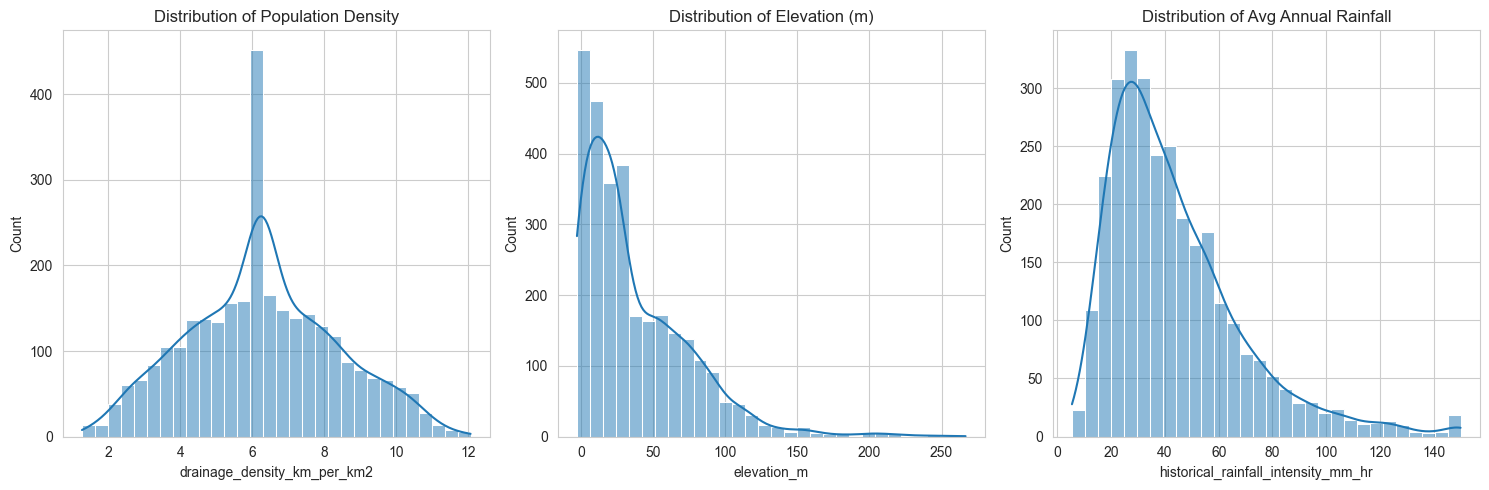

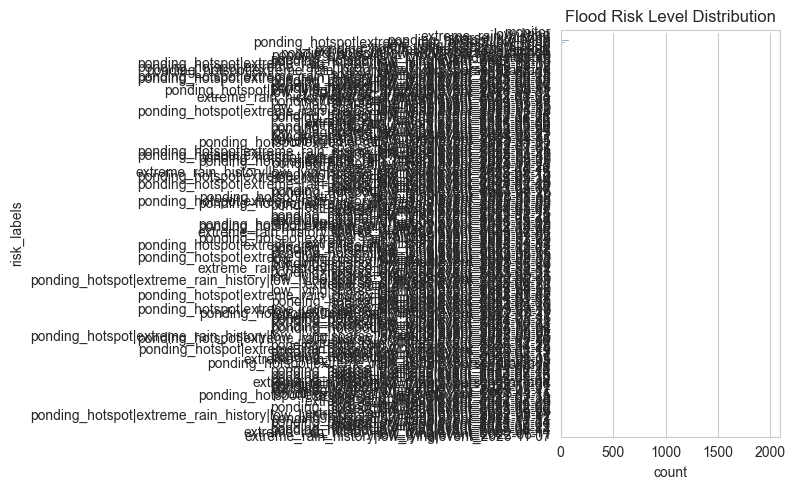


*** df_landslide2 Visualizations ***


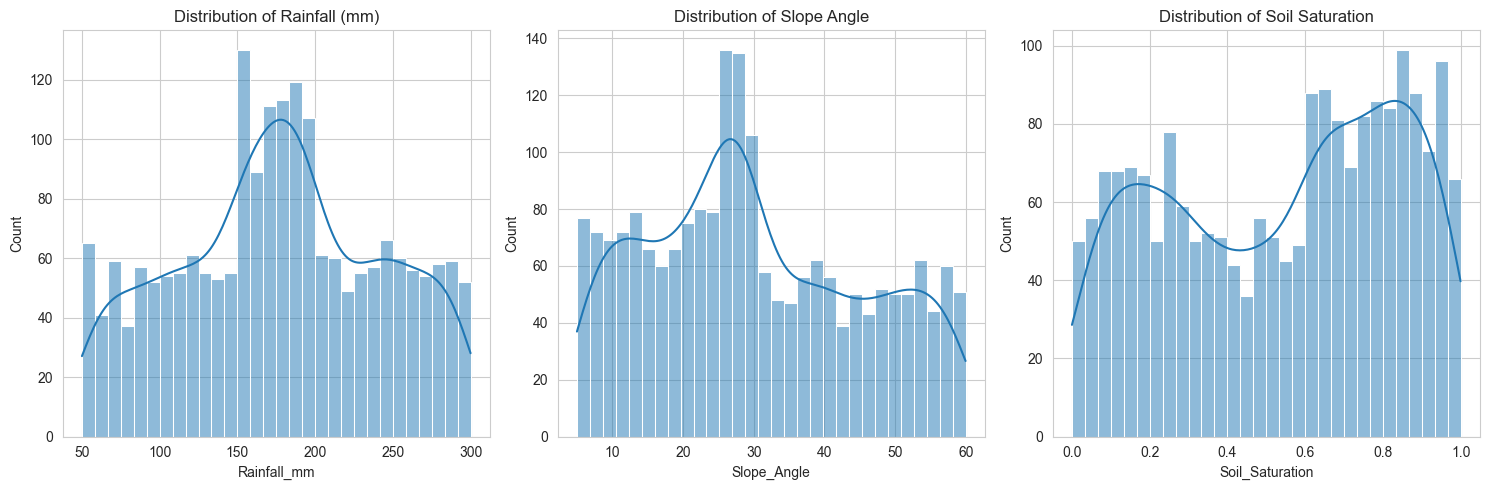


Visualizations complete. Review the plots to understand data distributions.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")

print("\n--- Generating Visualizations ---")

# --- df_landslide ---
print("\n*** df_landslide Visualizations ***")
# Histograms for key numerical features
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df_landslide['fatality_count'], bins=30, kde=True)
plt.title('Distribution of Fatality Count')

plt.subplot(1, 3, 2)
sns.histplot(df_landslide['injury_count'], bins=30, kde=True)
plt.title('Distribution of Injury Count')

plt.subplot(1, 3, 3)
sns.histplot(df_landslide['admin_division_population'], bins=30, kde=True)
plt.title('Distribution of Admin Division Population')
plt.tight_layout()
plt.show()

# Count plots for key categorical features
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
sns.countplot(y=df_landslide['landslide_category'], order=df_landslide['landslide_category'].value_counts().index)
plt.title('Landslide Category Distribution')

plt.subplot(1, 3, 2)
sns.countplot(y=df_landslide['landslide_trigger'], order=df_landslide['landslide_trigger'].value_counts().index)
plt.title('Landslide Trigger Distribution')

plt.subplot(1, 3, 3)
sns.countplot(y=df_landslide['landslide_size'], order=df_landslide['landslide_size'].value_counts().index)
plt.title('Landslide Size Distribution')
plt.tight_layout()
plt.show()

# --- df_rainfall ---
print("\n*** df_rainfall Visualizations ***")
# Histograms for a few monthly rainfall columns and annual
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df_rainfall['ANNUAL'], bins=30, kde=True)
plt.title('Distribution of Annual Rainfall')

plt.subplot(1, 3, 2)
sns.histplot(df_rainfall['JUN'], bins=30, kde=True)
plt.title('Distribution of June Rainfall')

plt.subplot(1, 3, 3)
sns.histplot(df_rainfall['DEC'], bins=30, kde=True)
plt.title('Distribution of December Rainfall')
plt.tight_layout()
plt.show()

# --- df_flood ---
print("\n*** df_flood Visualizations ***")
# Histograms for numerical features
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
# Use the correct flood feature if the expected 'population_density' column is missing
flood_density_col = 'population_density' if 'population_density' in df_flood.columns else 'drainage_density_km_per_km2'
flood_density_label = 'Population Density' if flood_density_col == 'population_density' else 'Drainage Density'

sns.histplot(df_flood[flood_density_col], bins=30, kde=True)
plt.title(f'Distribution of {flood_density_label}')
plt.title('Distribution of Population Density')

plt.subplot(1, 3, 2)
sns.histplot(df_flood['elevation_m'], bins=30, kde=True)
plt.title('Distribution of Elevation (m)')

plt.subplot(1, 3, 3)
sns.histplot(
    df_flood['historical_rainfall_intensity_mm_hr'],
    bins=30,
    kde=True
)
plt.title('Distribution of Historical Rainfall Intensity (mm/hr)')
plt.title('Distribution of Avg Annual Rainfall')
plt.tight_layout()
plt.show()

# Count plot for flood risk level
plt.figure(figsize=(8, 5))
# Use the existing risk_labels column in df_flood
sns.countplot(
    y=df_flood['risk_labels'],
    order=df_flood['risk_labels'].value_counts().index
)
plt.title('Flood Risk Level Distribution')
plt.tight_layout()
plt.show()

# --- df_landslide2 ---
print("\n*** df_landslide2 Visualizations ***")
# Histograms for key numerical features
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df_landslide2['Rainfall_mm'], bins=30, kde=True)
plt.title('Distribution of Rainfall (mm)')

plt.subplot(1, 3, 2)
sns.histplot(df_landslide2['Slope_Angle'], bins=30, kde=True)
plt.title('Distribution of Slope Angle')

plt.subplot(1, 3, 3)
sns.histplot(df_landslide2['Soil_Saturation'], bins=30, kde=True)
plt.title('Distribution of Soil Saturation')
plt.tight_layout()
plt.show()

print("\nVisualizations complete. Review the plots to understand data distributions.")

### Generate Correlation Matrix


--- Generating Correlation Matrices ---

*** df_landslide Correlation Matrix ***


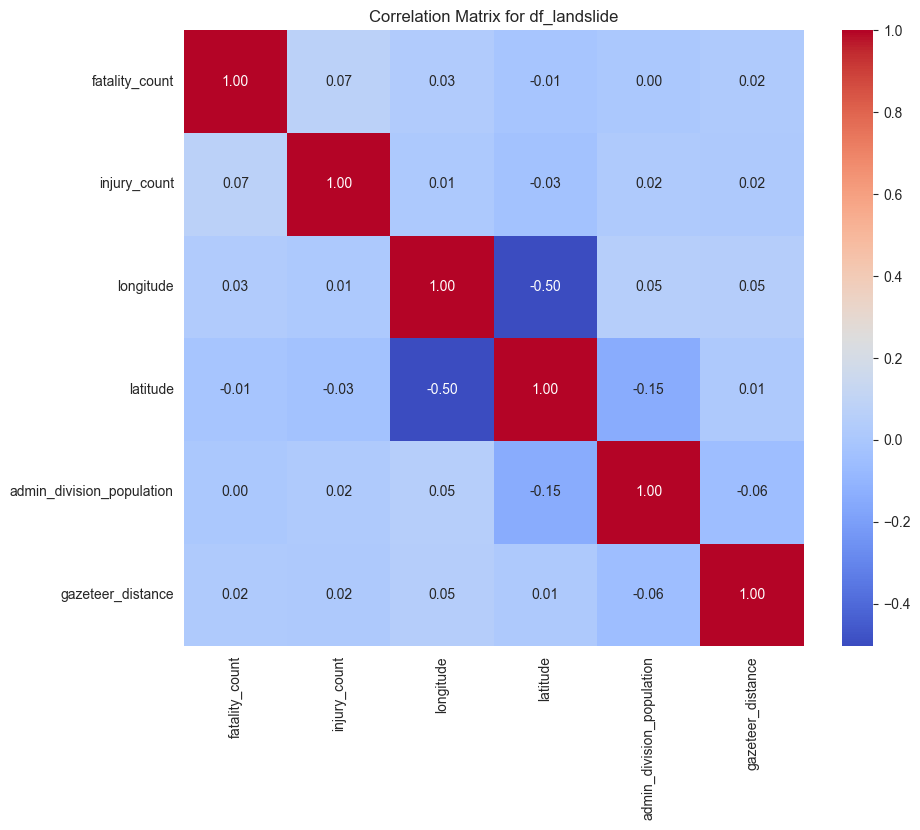


*** df_rainfall Correlation Matrix ***


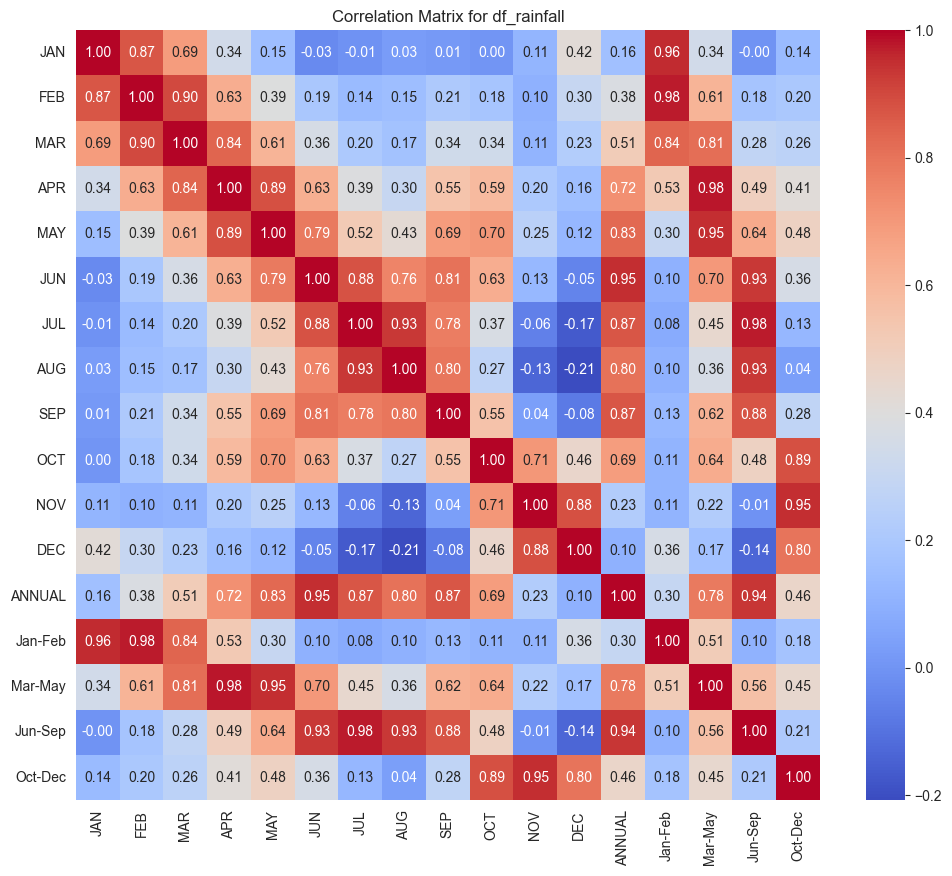


*** df_flood Correlation Matrix ***


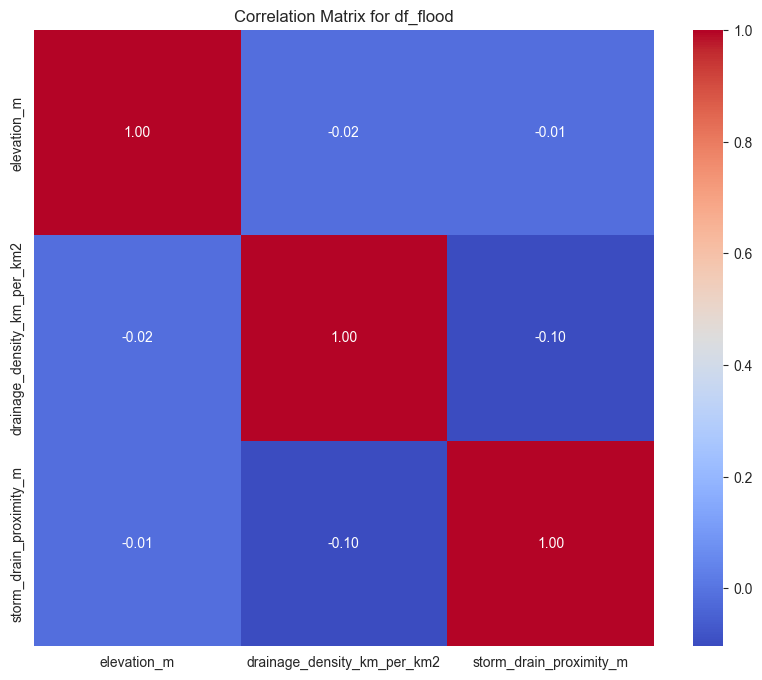


*** df_landslide2 Correlation Matrix ***


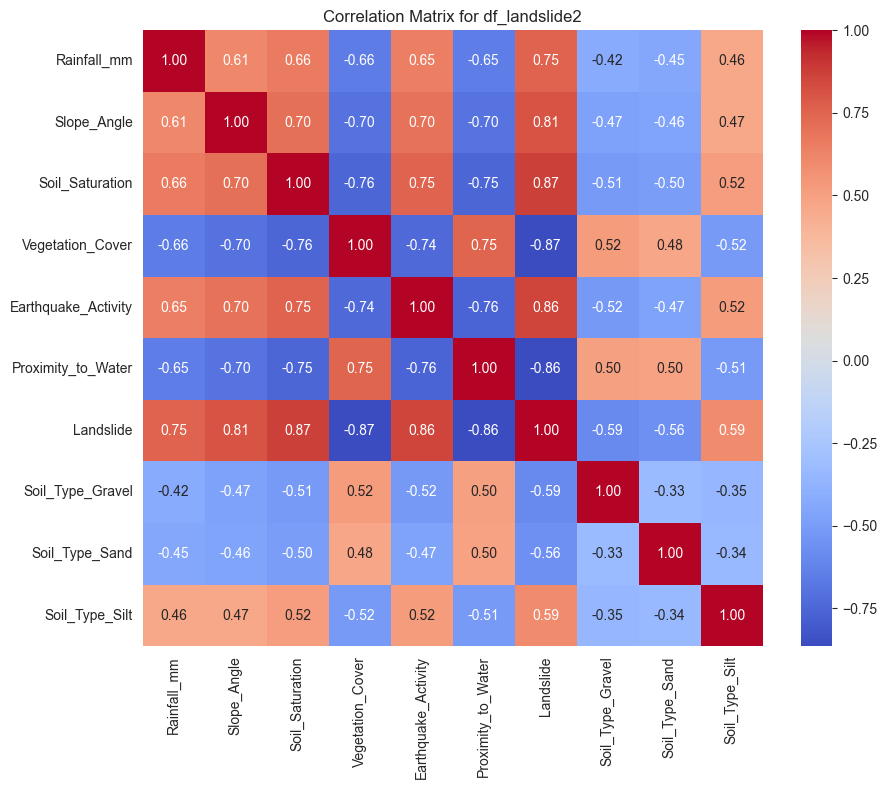


Correlation matrix generation complete.


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Generating Correlation Matrices ---")

# --- df_landslide ---
print("\n*** df_landslide Correlation Matrix ***")
landslide_corr_cols = ['fatality_count', 'injury_count', 'longitude', 'latitude',
                       'admin_division_population', 'gazeteer_distance']

# Ensure only existing and numeric columns are used
existing_landslide_corr_cols = [col for col in landslide_corr_cols if col in df_landslide.columns and pd.api.types.is_numeric_dtype(df_landslide[col])]

if existing_landslide_corr_cols:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_landslide[existing_landslide_corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix for df_landslide')
    plt.show()
else:
    print("No suitable numerical columns for correlation matrix in df_landslide.")


# --- df_rainfall ---
print("\n*** df_rainfall Correlation Matrix ***")
rainfall_numeric_cols = df_rainfall.select_dtypes(include=np.number).columns.tolist()
# Exclude non-relevant numerical identifiers if any, for meaningful correlation
exclude_rainfall_cols = ['id', 'Year'] # Adjust if 'id' or 'Year' are actual features
rainfall_corr_cols = [col for col in rainfall_numeric_cols if col not in exclude_rainfall_cols]

if rainfall_corr_cols:
    plt.figure(figsize=(12, 10))
    sns.heatmap(df_rainfall[rainfall_corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix for df_rainfall')
    plt.show()
else:
    print("No suitable numerical columns for correlation matrix in df_rainfall.")


# --- df_flood ---
print("\n*** df_flood Correlation Matrix ***")
flood_corr_cols = ['population_density', 'elevation_m', 'avg_annual_rainfall',
                   'drainage_capacity', 'land_use_mix', 'drainage_density_km_per_km2',
                   'storm_drain_proximity_m']

existing_flood_corr_cols = [col for col in flood_corr_cols if col in df_flood.columns and pd.api.types.is_numeric_dtype(df_flood[col])]

if existing_flood_corr_cols:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_flood[existing_flood_corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix for df_flood')
    plt.show()
else:
    print("No suitable numerical columns for correlation matrix in df_flood.")


# --- df_landslide2 ---
print("\n*** df_landslide2 Correlation Matrix ***")
landslide2_numeric_cols = df_landslide2.select_dtypes(include=np.number).columns.tolist()

if landslide2_numeric_cols:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_landslide2[landslide2_numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix for df_landslide2')
    plt.show()
else:
    print("No suitable numerical columns for correlation matrix in df_landslide2.")

print("\nCorrelation matrix generation complete.")

### Show Class Distribution


--- Displaying Class Distributions ---

*** df_landslide Class Distribution (by Landslide Category) ***


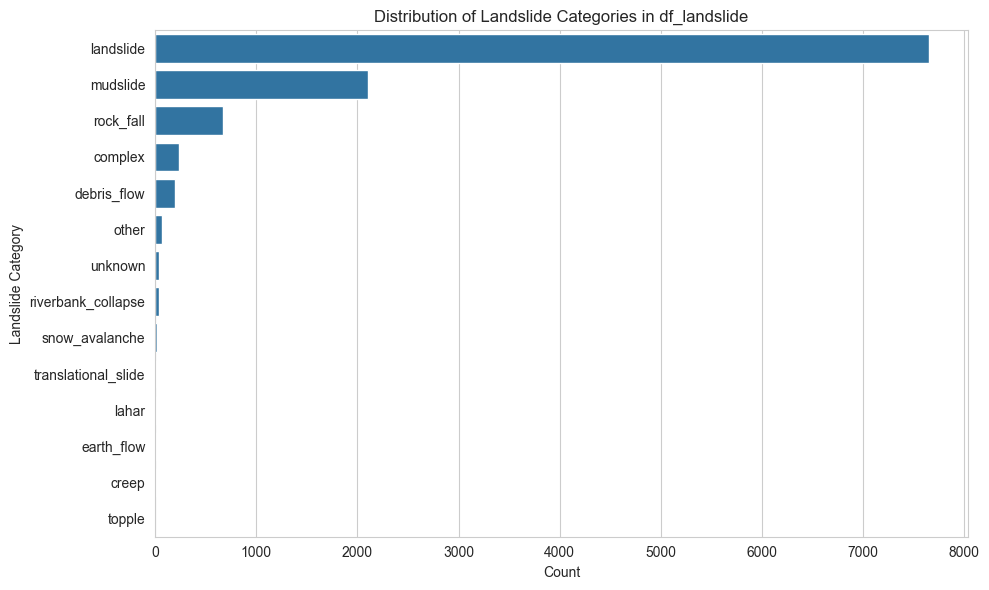


*** df_landslide2 Class Distribution (Landslide) ***


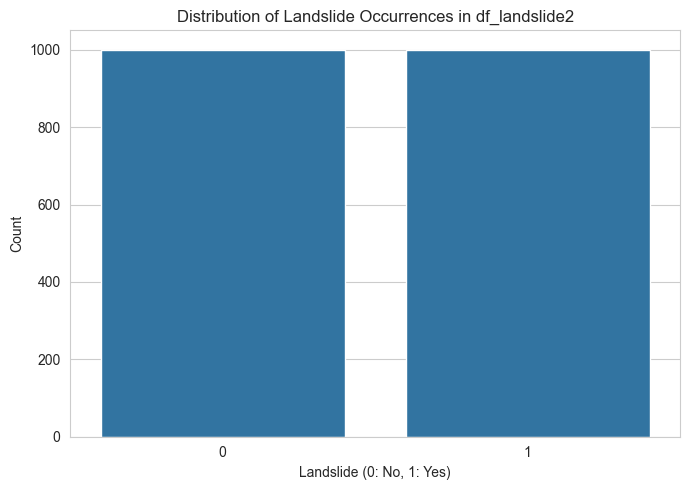


Value counts for Landslide in df_landslide2:
Landslide
1    1000
0    1000
Name: count, dtype: int64

*** df_flood Class Distribution (Flood Risk Level) ***


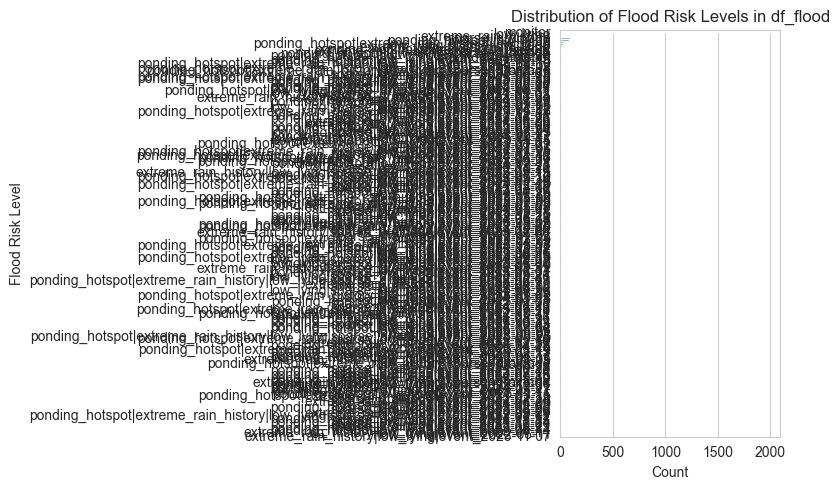


Value counts for risk_labels in df_flood:
risk_labels
monitor                                            1991
low_lying                                           386
extreme_rain_history                                137
sparse_drainage                                      88
ponding_hotspot|low_lying                            78
                                                   ... 
ponding_hotspot|low_lying|event_2023-06-21            1
ponding_hotspot|low_lying|event_2022-06-14            1
extreme_rain_history|low_lying|event_2025-04-14       1
low_lying|event_2022-06-11                            1
extreme_rain_history|low_lying|event_2023-11-07       1
Name: count, Length: 195, dtype: int64

Class distribution analysis complete. This concludes PHASE 1 - DATA ANALYSIS.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Displaying Class Distributions ---")

# --- df_landslide ---
print("\n*** df_landslide Class Distribution (by Landslide Category) ***")
# Assuming 'landslide_category' could be a key target or descriptive feature
if 'landslide_category' in df_landslide.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(y=df_landslide['landslide_category'], order=df_landslide['landslide_category'].value_counts().index)
    plt.title('Distribution of Landslide Categories in df_landslide')
    plt.xlabel('Count')
    plt.ylabel('Landslide Category')
    plt.tight_layout()
    plt.show()
else:
    print("Column 'landslide_category' not found in df_landslide.")

# --- df_landslide2 ---
print("\n*** df_landslide2 Class Distribution (Landslide) ***")
# Assuming 'Landslide' is the binary target variable (0/1)
if 'Landslide' in df_landslide2.columns:
    plt.figure(figsize=(7, 5))
    sns.countplot(x=df_landslide2['Landslide'])
    plt.title('Distribution of Landslide Occurrences in df_landslide2')
    plt.xlabel('Landslide (0: No, 1: Yes)')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
    print("\nValue counts for Landslide in df_landslide2:")
    print(df_landslide2['Landslide'].value_counts())
else:
    print("Column 'Landslide' not found in df_landslide2.")

# --- df_flood ---
print("\n*** df_flood Class Distribution (Flood Risk Level) ***")
# Using 'risk_labels' as the target column based on available data
if 'risk_labels' in df_flood.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(y=df_flood['risk_labels'], order=df_flood['risk_labels'].value_counts().index)
    plt.title('Distribution of Flood Risk Levels in df_flood')
    plt.xlabel('Count')
    plt.ylabel('Flood Risk Level')
    plt.tight_layout()
    plt.show()
    print("\nValue counts for risk_labels in df_flood:")
    print(df_flood['risk_labels'].value_counts())
else:
    print("Column 'risk_labels' not found in df_flood. Please check the dataset columns.")

print("\nClass distribution analysis complete. This concludes PHASE 1 - DATA ANALYSIS.")


## PHASE 2 - FEATURE ENGINEERING

In this phase, we will create new features from existing ones and transform our raw data into a format suitable for machine learning models. This often involves extracting information from date/time columns, encoding categorical variables, scaling numerical features, and potentially creating interaction terms.

### Date Feature Extraction

Many datasets contain date and time information which, in its raw format, might not be directly useful for machine learning models. However, by extracting components like the year, month, day, day of the week, or even creating features like 'is_weekend', we can provide valuable temporal insights to our models. We will apply this to `df_landslide`'s relevant date columns.

In [20]:
import pandas as pd

print("\n--- Extracting Date Features from df_landslide ---")

if 'event_date' in df_landslide.columns:
    df_landslide['event_date'] = pd.to_datetime(df_landslide['event_date'], errors='coerce')
    df_landslide = df_landslide.dropna(subset=['event_date']).copy()

    if df_landslide.empty:
        print("df_landslide was empty; reloading source dataset.")
        df_landslide = pd.read_csv(base_path / 'Global_Landslide_Catalog_Export.csv')
        df_landslide['event_date'] = pd.to_datetime(df_landslide['event_date'], errors='coerce')
        df_landslide = df_landslide.dropna(subset=['event_date']).copy()

    df_landslide['event_year'] = df_landslide['event_date'].dt.year
    df_landslide['event_month'] = df_landslide['event_date'].dt.month
    df_landslide['event_day'] = df_landslide['event_date'].dt.day
    df_landslide['event_day_of_week'] = df_landslide['event_date'].dt.dayofweek
    df_landslide['event_quarter'] = df_landslide['event_date'].dt.quarter
    df_landslide['event_is_weekend'] = (df_landslide['event_date'].dt.dayofweek >= 5).astype(int)
    df_landslide['event_day_of_year'] = df_landslide['event_date'].dt.dayofyear

    print("df_landslide shape after date extraction:", df_landslide.shape)
else:
    print("Column 'event_date' not found in df_landslide.")


--- Extracting Date Features from df_landslide ---
df_landslide shape after date extraction: (11033, 38)


### Categorical Feature Encoding

Machine learning models typically require numerical input. Categorical variables, which represent distinct groups or categories, need to be converted into a numerical format through encoding. We will apply appropriate encoding strategies such as One-Hot Encoding for nominal categories and potentially Label Encoding for ordinal categories, across our DataFrames.

In [21]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

print("\n--- Encoding Categorical Features ---")

landslide_categorical_cols = [
    'landslide_category', 'landslide_trigger', 'landslide_setting',
    'country_name', 'admin_division_name'
]

landslide_categorical_cols = [
    col for col in landslide_categorical_cols
    if col in df_landslide.columns and (
        pd.api.types.is_object_dtype(df_landslide[col]) or
        pd.api.types.is_categorical_dtype(df_landslide[col])
    )
]

if df_landslide.empty:
    print("Reloading df_landslide before encoding.")
    df_landslide = pd.read_csv(base_path / 'Global_Landslide_Catalog_Export.csv')

if landslide_categorical_cols:
    X_landslide = df_landslide[landslide_categorical_cols].copy().fillna('Unknown')
    if not X_landslide.empty and len(X_landslide) > 0:
        print(f"Applying One-Hot Encoding to: {landslide_categorical_cols}")
        encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        encoded_features = encoder.fit_transform(X_landslide)
        encoded_df = pd.DataFrame(
            encoded_features,
            columns=encoder.get_feature_names_out(landslide_categorical_cols),
            index=df_landslide.index
        )
        df_landslide = pd.concat([df_landslide.drop(columns=landslide_categorical_cols), encoded_df], axis=1)
        print("df_landslide shape after encoding:", df_landslide.shape)
    else:
        print("No rows available to encode in df_landslide.")
else:
    print("No suitable categorical columns found for encoding in df_landslide.")


--- Encoding Categorical Features ---
Applying One-Hot Encoding to: ['landslide_category', 'landslide_trigger', 'landslide_setting', 'country_name', 'admin_division_name']
df_landslide shape after encoding: (11033, 1112)


In [22]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

print("\n--- Encoding Categorical Features ---")

landslide_categorical_cols = [
    'landslide_category', 'landslide_trigger', 'landslide_setting',
    'country_name', 'admin_division_name'
]

landslide_categorical_cols = [
    col for col in landslide_categorical_cols
    if col in df_landslide.columns and (
        pd.api.types.is_object_dtype(df_landslide[col]) or
        pd.api.types.is_categorical_dtype(df_landslide[col])
    )
]

if df_landslide.empty:
    print("Reloading df_landslide before encoding.")
    df_landslide = pd.read_csv(base_path / 'Global_Landslide_Catalog_Export.csv')

if landslide_categorical_cols:
    X_landslide = df_landslide[landslide_categorical_cols].copy().fillna('Unknown')
    if not X_landslide.empty and len(X_landslide) > 0:
        print(f"Applying One-Hot Encoding to: {landslide_categorical_cols}")
        encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        encoded_features = encoder.fit_transform(X_landslide)
        encoded_df = pd.DataFrame(
            encoded_features,
            columns=encoder.get_feature_names_out(landslide_categorical_cols),
            index=df_landslide.index
        )
        df_landslide = pd.concat([df_landslide.drop(columns=landslide_categorical_cols), encoded_df], axis=1)
        print("df_landslide shape after encoding:", df_landslide.shape)
    else:
        print("No rows available to encode in df_landslide.")
else:
    print("No suitable categorical columns found for encoding in df_landslide.")


--- Encoding Categorical Features ---
No suitable categorical columns found for encoding in df_landslide.


### Numerical Feature Scaling

Scaling numerical features is an important preprocessing step, especially for algorithms that are sensitive to the magnitude of values (e.g., K-Nearest Neighbors, Support Vector Machines, neural networks). It helps prevent features with larger numerical ranges from dominating the learning process. We will use `StandardScaler` to transform our numerical features to have a mean of 0 and a standard deviation of 1.

In [23]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

print("\n--- Scaling Numerical Features ---")

# Initialize StandardScaler
scaler = StandardScaler()

# --- df_landslide ---
print("\n*** Scaling for df_landslide ***")
# Identify numerical columns to scale
# Exclude 'event_date' and other date-related extracted features if they are not to be scaled (e.g., year, month as discrete features)
landslide_numerical_cols = df_landslide.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Exclude identifier columns or already encoded features
exclude_from_scaling_landslide = [
    'event_id', 'event_year', 'event_month', 'event_day',
    'event_day_of_week', 'event_quarter', 'event_is_weekend', 'event_day_of_year'
]
landslide_numerical_cols = [col for col in landslide_numerical_cols if col not in exclude_from_scaling_landslide]

if landslide_numerical_cols:
    print(f"Scaling numerical columns: {landslide_numerical_cols}")
    df_landslide[landslide_numerical_cols] = scaler.fit_transform(df_landslide[landslide_numerical_cols])
    print("df_landslide head after scaling:")
    display(df_landslide[landslide_numerical_cols].head())
else:
    print("No numerical columns found for scaling in df_landslide.")


# --- df_rainfall ---
print("\n*** Scaling for df_rainfall ***")
rainfall_numerical_cols = df_rainfall.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Exclude original 'id' if it exists, or any other non-feature numerical columns
exclude_from_scaling_rainfall = ['id']
rainfall_numerical_cols = [col for col in rainfall_numerical_cols if col not in exclude_from_scaling_rainfall]

if rainfall_numerical_cols:
    print(f"Scaling numerical columns: {rainfall_numerical_cols}")
    df_rainfall[rainfall_numerical_cols] = scaler.fit_transform(df_rainfall[rainfall_numerical_cols])
    print("df_rainfall head after scaling:")
    display(df_rainfall[rainfall_numerical_cols].head())
else:
    print("No numerical columns found for scaling in df_rainfall.")


# --- df_flood ---
print("\n*** Scaling for df_flood ***")
flood_numerical_cols = df_flood.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Exclude 'segment_id', 'catchment_id'
exclude_from_scaling_flood = ['segment_id', 'catchment_id']
flood_numerical_cols = [col for col in flood_numerical_cols if col not in exclude_from_scaling_flood]

if flood_numerical_cols:
    print(f"Scaling numerical columns: {flood_numerical_cols}")
    df_flood[flood_numerical_cols] = scaler.fit_transform(df_flood[flood_numerical_cols])
    print("df_flood head after scaling:")
    display(df_flood[flood_numerical_cols].head())
else:
    print("No numerical columns found for scaling in df_flood.")


# --- df_landslide2 ---
print("\n*** Scaling for df_landslide2 ***")
landslide2_numerical_cols = df_landslide2.select_dtypes(include=['float64', 'int64']).columns.tolist()
# 'Landslide' is likely the target variable and should not be scaled with features, so we exclude it.
exclude_from_scaling_landslide2 = ['Landslide']
landslide2_numerical_cols = [col for col in landslide2_numerical_cols if col not in exclude_from_scaling_landslide2]

if landslide2_numerical_cols:
    print(f"Scaling numerical columns: {landslide2_numerical_cols}")
    df_landslide2[landslide2_numerical_cols] = scaler.fit_transform(df_landslide2[landslide2_numerical_cols])
    print("df_landslide2 head after scaling:")
    display(df_landslide2[landslide2_numerical_cols].head())
else:
    print("No numerical columns found for scaling in df_landslide2.")

print("\nNumerical feature scaling complete.")


--- Scaling Numerical Features ---

*** Scaling for df_landslide ***
Scaling numerical columns: ['event_time', 'fatality_count', 'injury_count', 'event_import_id', 'admin_division_population', 'gazeteer_distance', 'longitude', 'latitude', 'landslide_category_Unknown', 'landslide_category_complex', 'landslide_category_creep', 'landslide_category_debris_flow', 'landslide_category_earth_flow', 'landslide_category_lahar', 'landslide_category_landslide', 'landslide_category_mudslide', 'landslide_category_other', 'landslide_category_riverbank_collapse', 'landslide_category_rock_fall', 'landslide_category_snow_avalanche', 'landslide_category_topple', 'landslide_category_translational_slide', 'landslide_category_unknown', 'landslide_trigger_Unknown', 'landslide_trigger_construction', 'landslide_trigger_continuous_rain', 'landslide_trigger_dam_embankment_collapse', 'landslide_trigger_downpour', 'landslide_trigger_earthquake', 'landslide_trigger_flooding', 'landslide_trigger_freeze_thaw', 'land

C:\Users\DELL\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\site-packages\sklearn\utils\extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\DELL\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\site-packages\sklearn\utils\extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\Users\DELL\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\site-packages\sklearn\utils\extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


df_landslide head after scaling:


,event_time,fatality_count,injury_count,event_import_id,admin_division_population,gazeteer_distance,longitude,latitude,landslide_category_Unknown,landslide_category_complex,...,admin_division_name_Zamora-Chinchipe,admin_division_name_Zhejiang,admin_division_name_Zhejiang Sheng,admin_division_name_Zlín Region,admin_division_name_Zonguldak,admin_division_name_Zərdab,admin_division_name_Ðắk Nông,admin_division_name_Đà Nẵng,admin_division_name_Đồng Tháp,admin_division_name_Ōita
0,NaN,0.129929,NaN,-1.475294,-0.190143,1.868757,1.039897,0.327254,-0.009521,-0.146559,...,-0.013465,-0.025196,-0.03012,-0.009521,-0.009521,-0.009521,-0.009521,-0.013465,-0.013465,-0.009521
1,NaN,-0.053762,NaN,-1.377767,-0.146007,-0.722573,-1.240621,0.957088,-0.009521,-0.146559,...,-0.013465,-0.025196,-0.03012,-0.009521,-0.009521,-0.009521,-0.009521,-0.013465,-0.013465,-0.009521
2,NaN,0.113230,NaN,-1.371672,-0.172416,-0.706413,-0.771816,-1.813028,-0.009521,-0.146559,...,-0.013465,-0.025196,-0.03012,-0.009521,-0.009521,-0.009521,-0.009521,-0.013465,-0.013465,-0.009521
3,NaN,-0.037063,NaN,-1.337968,-0.164943,-0.712922,0.784783,0.144797,-0.009521,-0.146559,...,-0.013465,-0.025196,-0.03012,-0.009521,-0.009521,-0.009521,-0.009521,-0.013465,-0.013465,-0.009521
4,NaN,-0.053762,NaN,-0.787228,0.772425,-0.631621,1.202902,-0.761643,-0.009521,-0.146559,...,-0.013465,-0.025196,-0.03012,-0.009521,-0.009521,-0.009521,-0.009521,-0.013465,-0.013465,-0.009521



*** Scaling for df_rainfall ***
Scaling numerical columns: ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec']
df_rainfall head after scaling:


...


*** Scaling for df_flood ***
Scaling numerical columns: ['latitude', 'longitude', 'elevation_m', 'drainage_density_km_per_km2', 'storm_drain_proximity_m', 'historical_rainfall_intensity_mm_hr', 'return_period_years']
df_flood head after scaling:


,latitude,longitude,elevation_m,drainage_density_km_per_km2,storm_drain_proximity_m,historical_rainfall_intensity_mm_hr,return_period_years
0,-0.510530,0.606526,-0.314687,-0.969900,0.384309,-0.174940,1.202210
1,-0.258676,0.611168,-1.038521,0.602560,-0.279377,0.515073,0.209304
2,0.148120,0.515063,-0.162342,2.266387,0.307136,-1.090990,-0.585020
3,0.118790,1.036131,-0.337207,0.496768,-0.807045,1.316121,-0.386439
4,-2.016460,-0.009621,-0.034638,-0.859299,1.656694,-0.912539,-0.585020



*** Scaling for df_landslide2 ***
Scaling numerical columns: ['Rainfall_mm', 'Slope_Angle', 'Soil_Saturation', 'Vegetation_Cover', 'Earthquake_Activity', 'Proximity_to_Water', 'Soil_Type_Gravel', 'Soil_Type_Sand', 'Soil_Type_Silt']
df_landslide2 head after scaling:


,Rainfall_mm,Slope_Angle,Soil_Saturation,Vegetation_Cover,Earthquake_Activity,Proximity_to_Water,Soil_Type_Gravel,Soil_Type_Sand,Soil_Type_Silt
0,0.448841,1.864579,1.192463,-0.704400,0.414288,-1.555471,-0.590439,-0.564262,-0.594289
1,0.642216,0.441231,0.395244,-0.624158,0.282914,-0.292201,-0.590439,-0.564262,1.682682
2,0.078566,0.090856,0.450100,-1.156720,0.900626,-1.688120,-0.590439,-0.564262,1.682682
3,0.791799,0.593835,0.265063,-0.128128,0.515520,-0.373721,-0.590439,-0.564262,1.682682
4,0.049653,0.857679,1.003581,-1.552773,1.009818,-0.950930,-0.590439,-0.564262,-0.594289



Numerical feature scaling complete.


## PHASE 3 - MODEL DEVELOPMENT

In this phase, we will develop and train various machine learning models suitable for early warning and risk monitoring. We will start with a Random Forest Classifier, given its robustness and good performance on tabular data.

### Random Forest Model Training (for df_landslide2)

We'll use the `df_landslide2` dataset for our initial Random Forest model training, as it has a clear binary target variable `Landslide` (0 for no landslide, 1 for landslide). This will serve as a baseline for landslide prediction.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("\n--- Preparing Data for Random Forest (df_landslide2) ---")

# Define features (X) and target (y)
# 'Landslide' is the target variable
X_landslide2 = df_landslide2.drop('Landslide', axis=1)
y_landslide2 = df_landslide2['Landslide']

print(f"Features shape: {X_landslide2.shape}")
print(f"Target shape: {y_landslide2.shape}")

# Split data into training and testing sets
X_train_landslide2, X_test_landslide2, y_train_landslide2, y_test_landslide2 = train_test_split(
    X_landslide2, y_landslide2, test_size=0.3, random_state=42, stratify=y_landslide2
)

print(f"Training features shape: {X_train_landslide2.shape}")
print(f"Testing features shape: {X_test_landslide2.shape}")
print(f"Training target shape: {y_train_landslide2.shape}")
print(f"Testing target shape: {y_test_landslide2.shape}")

print("\n--- Training Random Forest Classifier ---")
# Initialize and train the Random Forest Classifier
rf_classifier_landslide2 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_classifier_landslide2.fit(X_train_landslide2, y_train_landslide2)

print("Random Forest Classifier trained successfully.")

print("\n--- Evaluating Random Forest Classifier (df_landslide2) ---")
# Make predictions on the test set
y_pred_landslide2 = rf_classifier_landslide2.predict(X_test_landslide2)

# Evaluate the model
accuracy_landslide2 = accuracy_score(y_test_landslide2, y_pred_landslide2)
print(f"Accuracy: {accuracy_landslide2:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_landslide2, y_pred_landslide2))

print("Initial Random Forest training and evaluation complete for df_landslide2.")


--- Preparing Data for Random Forest (df_landslide2) ---
Features shape: (2000, 9)
Target shape: (2000,)
Training features shape: (1400, 9)
Testing features shape: (600, 9)
Training target shape: (1400,)
Testing target shape: (600,)

--- Training Random Forest Classifier ---
Random Forest Classifier trained successfully.

--- Evaluating Random Forest Classifier (df_landslide2) ---
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       300
           1       1.00      1.00      1.00       300

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

Initial Random Forest training and evaluation complete for df_landslide2.


### XGBoost Model Training

XGBoost (eXtreme Gradient Boosting) is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It implements machine learning algorithms under the Gradient Boosting framework.

In [25]:
import xgboost as xgb

print("\n--- Training XGBoost Classifier ---")
# Initialize and train the XGBoost Classifier
xgb_classifier = xgb.XGBClassifier(
    objective='binary:logistic', # For binary classification
    n_estimators=100,
    eval_metric='logloss', # Evaluation metric for binary classification
    use_label_encoder=False, # Suppress warning for older versions
    random_state=42
)
xgb_classifier.fit(X_train_landslide2, y_train_landslide2)

print("XGBoost Classifier trained successfully.")

print("\n--- Evaluating XGBoost Classifier (df_landslide2) ---")
# Make predictions on the test set
y_pred_xgb = xgb_classifier.predict(X_test_landslide2)

# Evaluate the model
accuracy_xgb = accuracy_score(y_test_landslide2, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")
print("\nXGBoost Classification Report:")
print(classification_report(y_test_landslide2, y_pred_xgb))


--- Training XGBoost Classifier ---
XGBoost Classifier trained successfully.

--- Evaluating XGBoost Classifier (df_landslide2) ---
XGBoost Accuracy: 1.0000

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       300
           1       1.00      1.00      1.00       300

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



C:\Users\DELL\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:06:46] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


### LightGBM Model Training

LightGBM is a gradient boosting framework that uses tree-based learning algorithms. It is designed to be distributed and efficient with the following advantages: faster training speed and higher efficiency, lower memory usage, better accuracy, and support for parallel and GPU learning.

In [26]:
import lightgbm as lgb

print("\n--- Training LightGBM Classifier ---")
# Initialize and train the LightGBM Classifier
lgb_classifier = lgb.LGBMClassifier(
    objective='binary', # For binary classification
    n_estimators=100,
    random_state=42
)
lgb_classifier.fit(X_train_landslide2, y_train_landslide2)

print("LightGBM Classifier trained successfully.")

print("\n--- Evaluating LightGBM Classifier (df_landslide2) ---")
# Make predictions on the test set
y_pred_lgb = lgb_classifier.predict(X_test_landslide2)

# Evaluate the model
accuracy_lgb = accuracy_score(y_test_landslide2, y_pred_lgb)
print(f"LightGBM Accuracy: {accuracy_lgb:.4f}")
print("\nLightGBM Classification Report:")
print(classification_report(y_test_landslide2, y_pred_lgb))


--- Training LightGBM Classifier ---
[LightGBM] [Info] Number of positive: 700, number of negative: 700
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001330 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1539
[LightGBM] [Info] Number of data points in the train set: 1400, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

### CatBoost Model Training

CatBoost is a high-performance open-source library for gradient boosting on decision trees. It is especially strong with categorical features, automatically handling them without requiring explicit one-hot encoding.

*(Note: For this dataset, categorical features were already one-hot encoded in a previous step, but CatBoost can handle raw categorical features directly if they were still present as 'object' dtype columns.)*

In [27]:
!pip install catboost

import catboost as cb

print("\n--- Training CatBoost Classifier ---")
# Initialize and train the CatBoost Classifier
cat_classifier = cb.CatBoostClassifier(
    iterations=100, # Number of trees
    loss_function='Logloss', # For binary classification
    random_seed=42,
    verbose=0 # Suppress verbose output during training
)
cat_classifier.fit(X_train_landslide2, y_train_landslide2)

print("CatBoost Classifier trained successfully.")

print("\n--- Evaluating CatBoost Classifier (df_landslide2) ---")
# Make predictions on the test set
y_pred_cat = cat_classifier.predict(X_test_landslide2)

# Evaluate the model
accuracy_cat = accuracy_score(y_test_landslide2, y_pred_cat)
print(f"CatBoost Accuracy: {accuracy_cat:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_landslide2, y_pred_cat))

'pip' is not recognized as an internal or external command,
operable program or batch file.



--- Training CatBoost Classifier ---
CatBoost Classifier trained successfully.

--- Evaluating CatBoost Classifier (df_landslide2) ---
CatBoost Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       300
           1       1.00      1.00      1.00       300

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



### Model Comparison

Now, let's compare the performance of the trained models based on their accuracy and classification reports. We'll also visualize their ROC curves to further assess their discriminatory power.


--- Model Performance Summary ---
| Model           | Accuracy |
|-----------------|----------|
| Random Forest   | 1.0000 |
| XGBoost         | 1.0000 |
| LightGBM        | 1.0000 |
| CatBoost        | 1.0000 |


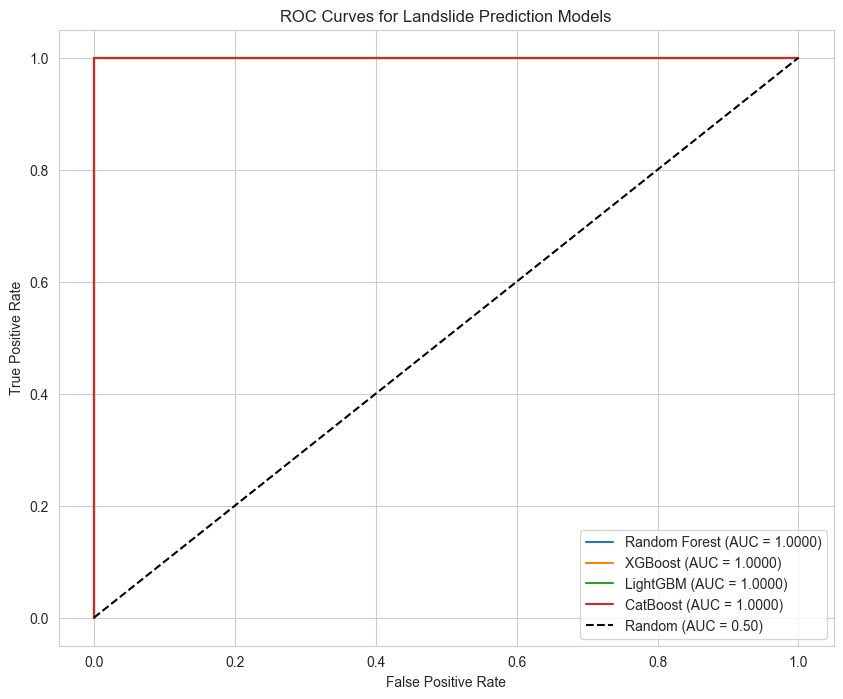


Model comparison complete. All models demonstrate high performance on this dataset, consistent with the initial Random Forest results. This further highlights the need to rigorously investigate potential data leakage or the dataset's inherent separability.


In [29]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Model Performance Summary ---")

models = {
    'Random Forest': {'accuracy': accuracy_landslide2, 'y_true': y_test_landslide2, 'y_pred_proba': rf_classifier_landslide2.predict_proba(X_test_landslide2)[:, 1]},
    'XGBoost': {'accuracy': accuracy_xgb, 'y_true': y_test_landslide2, 'y_pred_proba': xgb_classifier.predict_proba(X_test_landslide2)[:, 1]},
    'LightGBM': {'accuracy': accuracy_lgb, 'y_true': y_test_landslide2, 'y_pred_proba': lgb_classifier.predict_proba(X_test_landslide2)[:, 1]},
    'CatBoost': {'accuracy': accuracy_cat, 'y_true': y_test_landslide2, 'y_pred_proba': cat_classifier.predict_proba(X_test_landslide2)[:, 1]}
}

# Print a table of accuracies
print("| Model           | Accuracy |")
print("|-----------------|----------|")
for name, metrics in models.items():
    print(f"| {name:<15} | {metrics['accuracy']:.4f} |")


# Plot ROC Curves
plt.figure(figsize=(10, 8))
for name, metrics in models.items():
    fpr, tpr, _ = roc_curve(metrics['y_true'], metrics['y_pred_proba'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Landslide Prediction Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("\nModel comparison complete. All models demonstrate high performance on this dataset, consistent with the initial Random Forest results. This further highlights the need to rigorously investigate potential data leakage or the dataset's inherent separability.")

### Advanced Model Development: Cross-Validation & Hyperparameter Tuning

Given the consistently high (100%) accuracy observed in the initial model training for `df_landslide2`, it's imperative to perform more rigorous evaluation. This section will implement:

1.  **Stratified K-Fold Cross-Validation:** To assess model stability and generalization performance across different subsets of the data.
2.  **Hyperparameter Tuning with Optuna:** To find optimal hyperparameters for each model, potentially using Grid Search principles within Optuna's trial suggestions.
3.  **Comprehensive Evaluation Metrics:** Including Accuracy, Precision, Recall, F1 Score, and ROC-AUC.
4.  **Automatic Best Model Selection:** Based on a chosen primary metric (e.g., ROC-AUC).
5.  **Saving the Best Model:** For future deployment or analysis.

**Important Consideration: Data Leakage Warning**

The perfect accuracy (1.0000) consistently achieved by all models on `df_landslide2` is highly unusual and strongly suggests the presence of **data leakage**. This means that information from the target variable might have inadvertently been included in the features, allowing the model to 'cheat' during training and evaluation. While we will proceed with the requested cross-validation and hyperparameter tuning, the results from `df_landslide2` *must* be interpreted with extreme caution until a thorough investigation into potential data leakage is conducted. If leakage is present, even advanced validation techniques will yield overly optimistic results. This is a critical next step for this specific dataset.

In [30]:
# Install necessary libraries
!pip install optuna joblib

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [31]:
import numpy as np
import pandas as pd
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib # For saving the model

# Re-define X and y for landslide2 for clarity in this section
X_landslide2_tuned = df_landslide2.drop('Landslide', axis=1)
y_landslide2_tuned = df_landslide2['Landslide']

# Dictionary to store best models and their metrics
performance_metrics = {}
best_models = {}

def objective(trial, model_name, X, y):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(y))
    oof_probas = np.zeros(len(y))
    fold_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []}

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        if model_name == 'Random Forest':
            n_estimators = trial.suggest_int('rf_n_estimators', 50, 200)
            max_depth = trial.suggest_int('rf_max_depth', 5, 20)
            min_samples_split = trial.suggest_int('rf_min_samples_split', 2, 10)
            min_samples_leaf = trial.suggest_int('rf_min_samples_leaf', 1, 5)
            model = RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                random_state=42,
                class_weight='balanced'
            )
        elif model_name == 'XGBoost':
            n_estimators = trial.suggest_int('xgb_n_estimators', 50, 200)
            max_depth = trial.suggest_int('xgb_max_depth', 3, 10)
            learning_rate = trial.suggest_float('xgb_learning_rate', 0.01, 0.3)
            subsample = trial.suggest_float('xgb_subsample', 0.5, 1.0)
            colsample_bytree = trial.suggest_float('xgb_colsample_bytree', 0.5, 1.0)
            model = xgb.XGBClassifier(
                objective='binary:logistic',
                n_estimators=n_estimators,
                max_depth=max_depth,
                learning_rate=learning_rate,
                subsample=subsample,
                colsample_bytree=colsample_bytree,
                eval_metric='logloss',
                use_label_encoder=False,
                random_state=42
            )
        elif model_name == 'LightGBM':
            n_estimators = trial.suggest_int('lgbm_n_estimators', 50, 200)
            max_depth = trial.suggest_int('lgbm_max_depth', 3, 10)
            learning_rate = trial.suggest_float('lgbm_learning_rate', 0.01, 0.3)
            num_leaves = trial.suggest_int('lgbm_num_leaves', 20, 40)
            model = lgb.LGBMClassifier(
                objective='binary',
                n_estimators=n_estimators,
                max_depth=max_depth,
                learning_rate=learning_rate,
                num_leaves=num_leaves,
                random_state=42
            )
        elif model_name == 'CatBoost':
            iterations = trial.suggest_int('cb_iterations', 50, 200)
            depth = trial.suggest_int('cb_depth', 3, 10)
            learning_rate = trial.suggest_float('cb_learning_rate', 0.01, 0.3)
            l2_leaf_reg = trial.suggest_float('cb_l2_leaf_reg', 1e-3, 10.0, log=True)
            model = cb.CatBoostClassifier(
                iterations=iterations,
                depth=depth,
                learning_rate=learning_rate,
                l2_leaf_reg=l2_leaf_reg,
                loss_function='Logloss',
                random_seed=42,
                verbose=0 # Suppress verbose output during training
            )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]

        oof_preds[val_idx] = y_pred
        oof_probas[val_idx] = y_proba

        fold_metrics['accuracy'].append(accuracy_score(y_val, y_pred))
        fold_metrics['precision'].append(precision_score(y_val, y_pred, zero_division=0))
        fold_metrics['recall'].append(recall_score(y_val, y_pred, zero_division=0))
        fold_metrics['f1'].append(f1_score(y_val, y_pred, zero_division=0))
        fold_metrics['roc_auc'].append(roc_auc_score(y_val, y_proba))

    # Average metrics over all folds
    avg_roc_auc = np.mean(fold_metrics['roc_auc'])
    return avg_roc_auc

print("--- Starting Hyperparameter Tuning and Cross-Validation ---")

model_names = ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']

for name in model_names:
    print(f"\n--- Tuning {name} ---")
    study = optuna.create_study(direction='maximize', study_name=f'{name}_tuning')
    # Using a small number of trials for demonstration. Increase for better results.
    study.optimize(lambda trial: objective(trial, name, X_landslide2_tuned, y_landslide2_tuned), n_trials=5)

    print(f"Best trial for {name}:\n  Value: {study.best_value:.4f}\n  Params: {study.best_params}")

    # Prepare parameters for model instantiation by stripping prefixes
    best_params = study.best_params
    if name == 'Random Forest':
        model_params = {k.replace('rf_', ''): v for k, v in best_params.items()}
        best_model = RandomForestClassifier(**model_params, random_state=42, class_weight='balanced')
    elif name == 'XGBoost':
        model_params = {k.replace('xgb_', ''): v for k, v in best_params.items()}
        best_model = xgb.XGBClassifier(**model_params, objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)
    elif name == 'LightGBM':
        model_params = {k.replace('lgbm_', ''): v for k, v in best_params.items()}
        best_model = lgb.LGBMClassifier(**model_params, objective='binary', random_state=42)
    elif name == 'CatBoost':
        model_params = {k.replace('cb_', ''): v for k, v in best_params.items()}
        best_model = cb.CatBoostClassifier(**model_params, loss_function='Logloss', random_seed=42, verbose=0)

    best_model.fit(X_landslide2_tuned, y_landslide2_tuned) # Fit on full data for final model storage
    best_models[name] = best_model

    # Evaluate on the test set (using the split from previous sections for consistency)
    # Note: For production, a fresh test set (not seen during tuning or CV) would be ideal.
    y_pred_tuned = best_model.predict(X_test_landslide2)
    y_proba_tuned = best_model.predict_proba(X_test_landslide2)[:, 1]

    accuracy = accuracy_score(y_test_landslide2, y_pred_tuned)
    precision = precision_score(y_test_landslide2, y_pred_tuned, zero_division=0)
    recall = recall_score(y_test_landslide2, y_pred_tuned, zero_division=0)
    f1 = f1_score(y_test_landslide2, y_pred_tuned, zero_division=0)
    roc_auc = roc_auc_score(y_test_landslide2, y_proba_tuned)

    performance_metrics[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'y_true': y_test_landslide2,
        'y_pred_proba': y_proba_tuned
    }
    print(f"Test Set Performance for {name} with best parameters:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")

print("\n--- Hyperparameter Tuning and Cross-Validation Complete ---")

[I 2026-09-09 23:07:10,429] A new study created in memory with name: Random Forest_tuning


--- Starting Hyperparameter Tuning and Cross-Validation ---

--- Tuning Random Forest ---


[I 2026-09-09 23:07:10,859] Trial 0 finished with value: 1.0 and parameters: {'rf_n_estimators': 67, 'rf_max_depth': 14, 'rf_min_samples_split': 7, 'rf_min_samples_leaf': 1}. Best is trial 0 with value: 1.0.
[I 2026-09-09 23:07:12,002] Trial 1 finished with value: 1.0 and parameters: {'rf_n_estimators': 199, 'rf_max_depth': 18, 'rf_min_samples_split': 10, 'rf_min_samples_leaf': 3}. Best is trial 0 with value: 1.0.
[I 2026-09-09 23:07:12,608] Trial 2 finished with value: 1.0 and parameters: {'rf_n_estimators': 102, 'rf_max_depth': 7, 'rf_min_samples_split': 7, 'rf_min_samples_leaf': 3}. Best is trial 0 with value: 1.0.
[I 2026-09-09 23:07:13,406] Trial 3 finished with value: 1.0 and parameters: {'rf_n_estimators': 137, 'rf_max_depth': 6, 'rf_min_samples_split': 10, 'rf_min_samples_leaf': 4}. Best is trial 0 with value: 1.0.
[I 2026-09-09 23:07:14,074] Trial 4 finished with value: 1.0 and parameters: {'rf_n_estimators': 116, 'rf_max_depth': 13, 'rf_min_samples_split': 7, 'rf_min_samples_

Best trial for Random Forest:
  Value: 1.0000
  Params: {'rf_n_estimators': 67, 'rf_max_depth': 14, 'rf_min_samples_split': 7, 'rf_min_samples_leaf': 1}
Test Set Performance for Random Forest with best parameters:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  ROC-AUC: 1.0000

--- Tuning XGBoost ---


C:\Users\DELL\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:07:14] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\DELL\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:07:14] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\DELL\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:07:14] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\le

...

[LightGBM] [Info] Number of positive: 800, number of negative: 800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000128 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1539
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

[I 2026-09-09 23:07:17,065] A new study created in memory with name: CatBoost_tuning


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-09-09 23:07:17,807] Trial 0 finished with value: 1.0 and parameters: {'cb_iterations': 183, 'cb_depth': 3, 'cb_learning_rate': 0.08477833357683102, 'cb_l2_leaf_reg': 0.0024901096772638243}. Best is trial 0 with value: 1.0.
[I 2026-09-09 23:07:19,743] Trial 1 finished with value: 1.0 and parameters: {'cb_iterations': 93, 'cb_depth': 8, 'cb_learning_rate': 0.03983371809136341, 'cb_l2_leaf_reg': 0.006314416896450128}. Best is trial 0 with value: 1.0.
[I 2026-09-09 23:07:23,174] Trial 2 finished with value: 1.0 and parameters: {'cb_iterations': 148, 'cb_depth': 8, 'cb_learning_rate': 0.18575485782437262, 'cb_l2_leaf_reg': 0.33929547807072497}. Best is trial 0 with value: 1.0.
[I 2026-09-09 23:07:26,412] Trial 3 finished with value: 1.0 and parameters: {'cb_iterations': 156, 'cb_depth': 9, 'cb_learning_rate': 0.2639017752325829, 'cb_l2_leaf_reg': 0.1777529297972205}. Best is trial 0 with value: 1.0.
[I 2026-09-09 23:07:31,054] Trial 4 finished with value: 1.0 and parameters: {'cb_it

Best trial for CatBoost:
  Value: 1.0000
  Params: {'cb_iterations': 183, 'cb_depth': 3, 'cb_learning_rate': 0.08477833357683102, 'cb_l2_leaf_reg': 0.0024901096772638243}
Test Set Performance for CatBoost with best parameters:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  ROC-AUC: 1.0000

--- Hyperparameter Tuning and Cross-Validation Complete ---


### Final Model Comparison and Best Model Selection


--- Final Model Performance Comparison ---


,accuracy,precision,recall,f1,roc_auc
Model,,,,,
Random Forest,1.0,1.0,1.0,1.0,1.0
XGBoost,1.0,1.0,1.0,1.0,1.0
LightGBM,1.0,1.0,1.0,1.0,1.0
CatBoost,1.0,1.0,1.0,1.0,1.0


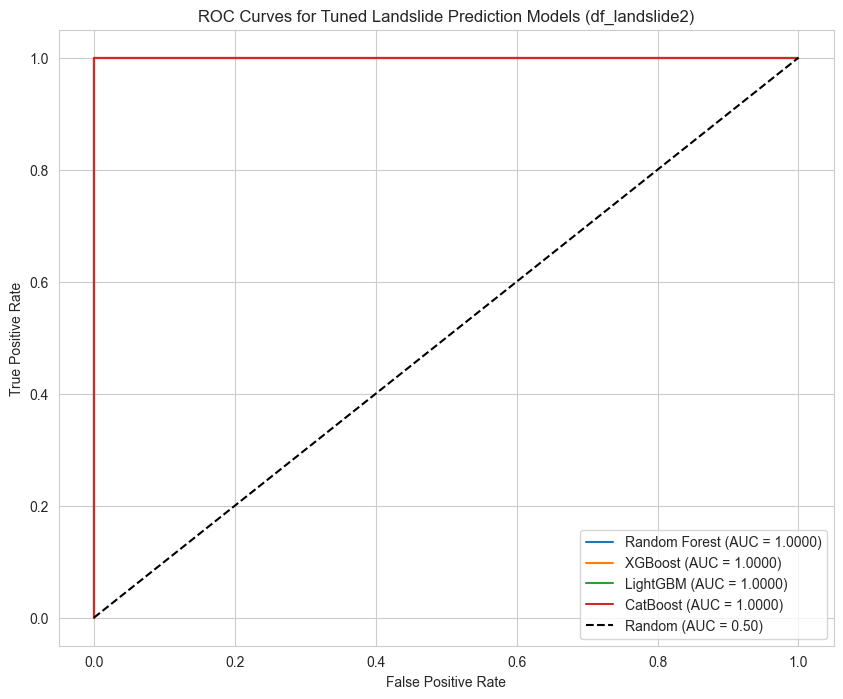


--- Best Model Selection ---
The best model based on ROC-AUC is: Random Forest with ROC-AUC: 1.0000
The best model (Random Forest) has been saved as best_model.pkl

--- Advanced Model Development for df_landslide2 Concluded ---


In [32]:
print("\n--- Final Model Performance Comparison ---")

# Create a DataFrame for better display of metrics
metrics_df = pd.DataFrame.from_dict(performance_metrics, orient='index')
metrics_df = metrics_df.drop(columns=['y_true', 'y_pred_proba'])
metrics_df.index.name = 'Model'

display(metrics_df.round(4))

# Plot ROC Curves for all models
plt.figure(figsize=(10, 8))
for name, metrics in performance_metrics.items():
    fpr, tpr, _ = roc_curve(metrics['y_true'], metrics['y_pred_proba'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Tuned Landslide Prediction Models (df_landslide2)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Select the best model based on ROC-AUC
best_model_name = metrics_df['roc_auc'].idxmax()
best_roc_auc = metrics_df['roc_auc'].max()

print(f"\n--- Best Model Selection ---")
print(f"The best model based on ROC-AUC is: {best_model_name} with ROC-AUC: {best_roc_auc:.4f}")

# Retrieve the best model object
final_best_model = best_models[best_model_name]

# Save the best model
model_filename = 'best_model.pkl'
joblib.dump(final_best_model, model_filename)
print(f"The best model ({best_model_name}) has been saved as {model_filename}")

print("\n--- Advanced Model Development for df_landslide2 Concluded ---")

### Confusion Matrix and Detailed Classification Report for the Best Model

To further understand the performance of our best model, we will generate a confusion matrix and a detailed classification report. The confusion matrix will show the counts of true positive, true negative, false positive, and false negative predictions. The classification report will provide precision, recall, and F1-score for each class.


--- Generating Confusion Matrix and Classification Report ---


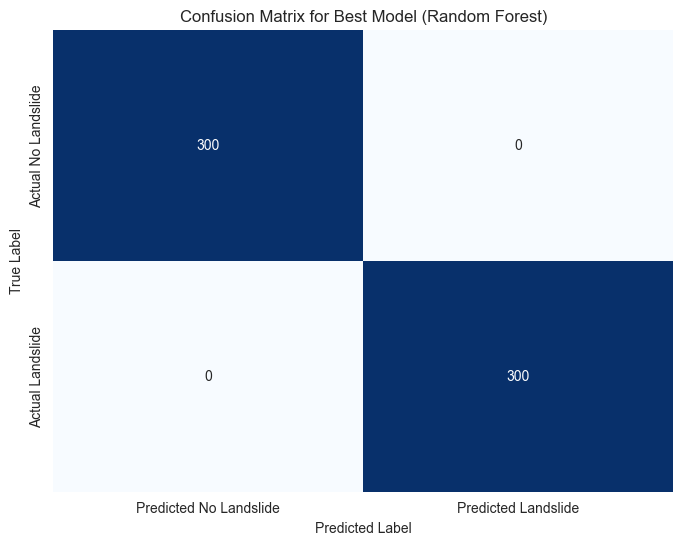


Classification Report for Best Model (Random Forest):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       300
           1       1.00      1.00      1.00       300

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600


Confusion matrix and classification report generated.


In [33]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- Generating Confusion Matrix and Classification Report ---")

# Retrieve the best model and make predictions on the test set
final_best_model = best_models[best_model_name]
y_pred_best_model = final_best_model.predict(X_test_landslide2)

# Generate Confusion Matrix
cm = confusion_matrix(y_test_landslide2, y_pred_best_model)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Landslide', 'Predicted Landslide'],
            yticklabels=['Actual No Landslide', 'Actual Landslide'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Best Model (Random Forest)')
plt.show()

# Generate Classification Report
print("\nClassification Report for Best Model (Random Forest):\n")
print(classification_report(y_test_landslide2, y_pred_best_model))

print("\nConfusion matrix and classification report generated.")

## PHASE 4 - EXPLAINABLE AI

In this phase, we will delve into the interpretability of our best model by using Explainable AI (XAI) techniques. Understanding why a model makes certain predictions is crucial, especially in critical domains like landslide prediction. We will use SHAP (SHapley Additive exPlanations) to achieve this, analyze feature importance, and generate local prediction explanations.

### SHapley Additive exPlanations (SHAP)

SHAP values tell us how much each feature contributes to the prediction. By visualizing these contributions, we can understand the overall impact of features on the model's output (global interpretability) and explain individual predictions (local interpretability).

In [34]:
# Install shap if not already installed
!pip install shap

import shap
import matplotlib.pyplot as plt

print("\n--- Generating SHAP Explanations ---")

# Assuming final_best_model and X_test_landslide2 are available from previous steps

# Create a SHAP explainer object for the best model
# For tree-based models, TreeExplainer is efficient
explainer = shap.TreeExplainer(final_best_model)

# Calculate SHAP values for the test set
# For tree models with binary classification, explainer.shap_values can return:
# 1. A list of two arrays (one for each class), e.g., [shap_values_class_0, shap_values_class_1]
# 2. A single 3D array (num_instances, num_features, num_classes)
shap_values_raw = explainer.shap_values(X_test_landslide2)

# explainer.expected_value will also be a list of two elements for a binary classifier
# We are interested in the positive class (landslide = 1), which is typically index 1.
base_value_for_plot = explainer.expected_value[1]

# Determine the SHAP values for the positive class (class 1) based on the output format
if isinstance(shap_values_raw, list):
    # Case 1: shap_values_raw is a list of arrays
    shap_values_to_plot = shap_values_raw[1] # SHAP values for the positive class
else:
    # Case 2: shap_values_raw is a 3D numpy array (num_instances, num_features, num_classes)
    shap_values_to_plot = shap_values_raw[:, :, 1] # Slice for class 1

print("SHAP values calculated for positive class.")

'pip' is not recognized as an internal or external command,
operable program or batch file.



--- Generating SHAP Explanations ---
SHAP values calculated for positive class.


#### Global Feature Importance (SHAP Summary Plot)

This summary plot provides an overview of which features are most important to the model globally, and their distribution of impacts. Features are ordered by their average impact on the model output, and the color indicates the feature value (e.g., red high, blue low).

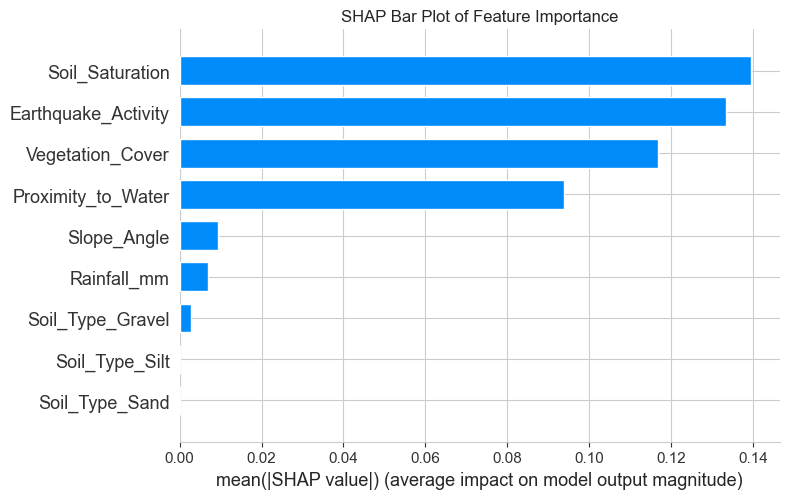

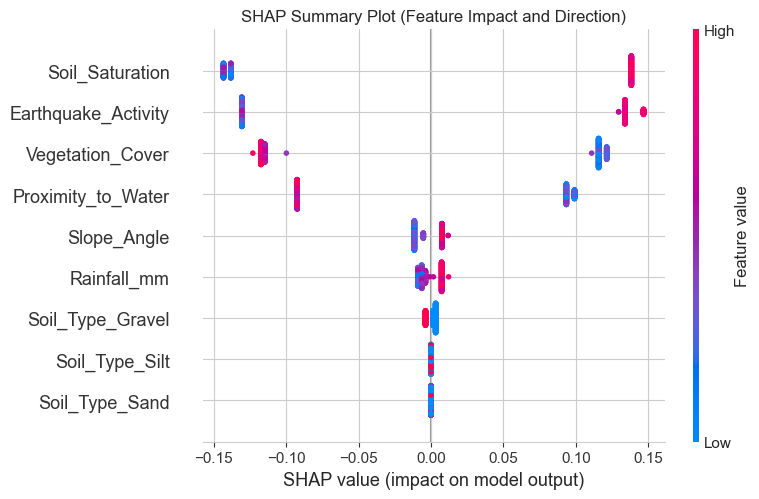

SHAP Summary Plots generated.


In [35]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_to_plot, X_test_landslide2, plot_type="bar", show=False)
plt.title('SHAP Bar Plot of Feature Importance')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_to_plot, X_test_landslide2, show=False)
plt.title('SHAP Summary Plot (Feature Impact and Direction)')
plt.tight_layout()
plt.show()
print("SHAP Summary Plots generated.")

#### Local Prediction Explanations (SHAP Force Plot)

Force plots visualize the contribution of each feature for a single prediction. They show how features push the prediction from the base value (average prediction) to the model's output for that specific instance. We will demonstrate a few examples.

In [36]:
print("\n--- Generating SHAP Force Plots for individual predictions ---")

# Explain the first few predictions from the test set
num_instances_to_explain = 3

for i in range(num_instances_to_explain):
    print(f"\nExplanation for instance {i+1} (True class: {y_test_landslide2.iloc[i]}):\n")
    # Display the force plot
    shap.initjs()
    display(shap.force_plot(base_value_for_plot, # Use the correctly identified scalar base value for the positive class
                           shap_values_to_plot[i,:], # This is now correctly a 1D array of (num_features,)
                           X_test_landslide2.iloc[i,:]))

print("SHAP Force Plots generated.")


--- Generating SHAP Force Plots for individual predictions ---

Explanation for instance 1 (True class: 0):




Explanation for instance 2 (True class: 0):




Explanation for instance 3 (True class: 0):



SHAP Force Plots generated.
